In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import missingno as msno
from plotnine import *
import folium

전국 도시 공원정보 표준 데이터

공공데이터포털( https://www.data.go.kr/ )에서 '소상공인시장진흥공단'를 검색한다.  
<img src="./전국도시공원정보표준데이터1.png" width="1000" align="left" />

<img src="./전국도시공원정보표준데이터2.png" width="1000" align="left" />

<img src="./전국도시공원정보표준데이터3.png" width="1000" align="left" />

다운받은 데이터를 로드하고 관찰한다.

In [2]:
park_202607_df = pd.read_csv('./data/park_202607.csv', encoding='cp949')
park_202607_df

,관리번호,공원명,공원구분,소재지도로명주소,소재지지번주소,위도,경도,공원면적,공원보유시설(운동시설),공원보유시설(유희시설),공원보유시설(편익시설),공원보유시설(교양시설),공원보유시설(기타시설),지정고시일,관리기관명,전화번호,데이터기준일자,제공기관코드,제공기관명
0,26200-00001,태종대유원지,기타,부산광역시 영도구 전망로 24,부산광역시 영도구 동삼동 산 19-2,35.059695,129.079806,1713763.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-04,B552974,부산관광공사
1,26110-00001,용두산공원,근린공원,부산광역시 중구 용두산길 37-55,부산광역시 중구 광복동 2가 1-2,35.100209,129.032278,70812.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-04,B552974,부산관광공사
2,29200-00028,월전공원,근린공원,-,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5,NaN,NaN,NaN,NaN,NaN,1991-06-25,광주광역시 광산구,062-960-6839,2026-06-29,6290000,광주광역시
3,29140-00054,극락어린이공원,어린이공원,-,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3,NaN,NaN,NaN,NaN,NaN,1996-07-11,광주광역시 서구청,062-360-7697,2026-06-29,6290000,광주광역시
4,29140-00053,서광어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2,NaN,NaN,NaN,NaN,NaN,1996-07-11,광주광역시 서구청,062-360-7697,2026-06-29,6290000,광주광역시
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18494,29110-00012,율곡,어린이공원,NaN,광주광역시 동구 산수동 708,35.159856,126.937268,4216.0,NaN,"조합놀이대, 그네, 흔들놀이기구",NaN,NaN,NaN,1990-12-12,광주광역시 동구청,062-608-2965,2025-02-21,3590000,광주광역시 동구
18495,29110-00044,천변,수변공원,NaN,광주광역시 동구 수기동 138,35.149929,126.909259,108420.0,NaN,NaN,NaN,NaN,NaN,1975-02-18,광주광역시 동구청,062-608-2965,2025-02-21,3590000,광주광역시 동구
18496,29110-00043,계림8,문화공원,광주광역시 동구 독립로 310 (계림동),광주광역시 동구 계림동 962,35.158152,126.913944,5999.0,NaN,NaN,NaN,NaN,NaN,2007-09-11,광주광역시 동구청,062-608-2965,2025-02-21,3590000,광주광역시 동구
18497,29110-00042,학동,역사공원,광주광역시 동구 천변우로 599 (학동),광주광역시 동구 학동 1013,35.131138,126.926317,2049.3,NaN,NaN,NaN,NaN,NaN,2005-11-01,광주광역시 동구청,062-608-2965,2025-02-21,3590000,광주광역시 동구


In [3]:
# park_202607_df.dtypes
park_202607_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18499 entries, 0 to 18498
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   관리번호          18499 non-null  str    
 1   공원명           18499 non-null  str    
 2   공원구분          18499 non-null  str    
 3   소재지도로명주소      3140 non-null   str    
 4   소재지지번주소       18310 non-null  str    
 5   위도            18499 non-null  float64
 6   경도            18499 non-null  float64
 7   공원면적          18499 non-null  float64
 8   공원보유시설(운동시설)  5370 non-null   str    
 9   공원보유시설(유희시설)  6252 non-null   str    
 10  공원보유시설(편익시설)  5110 non-null   str    
 11  공원보유시설(교양시설)  548 non-null    str    
 12  공원보유시설(기타시설)  2747 non-null   str    
 13  지정고시일         15230 non-null  str    
 14  관리기관명         17507 non-null  str    
 15  전화번호          17526 non-null  str    
 16  데이터기준일자       18499 non-null  str    
 17  제공기관코드        18499 non-null  str    
 18  제공기관명         18499 non-null  str    

In [4]:
# park_202607_df.isnull().sum()
park_202607_df.isna().sum()

관리번호                0
공원명                 0
공원구분                0
소재지도로명주소        15359
소재지지번주소           189
위도                  0
경도                  0
공원면적                0
공원보유시설(운동시설)    13129
공원보유시설(유희시설)    12247
공원보유시설(편익시설)    13389
공원보유시설(교양시설)    17951
공원보유시설(기타시설)    15752
지정고시일            3269
관리기관명             992
전화번호              973
데이터기준일자             0
제공기관코드              0
제공기관명               0
dtype: int64

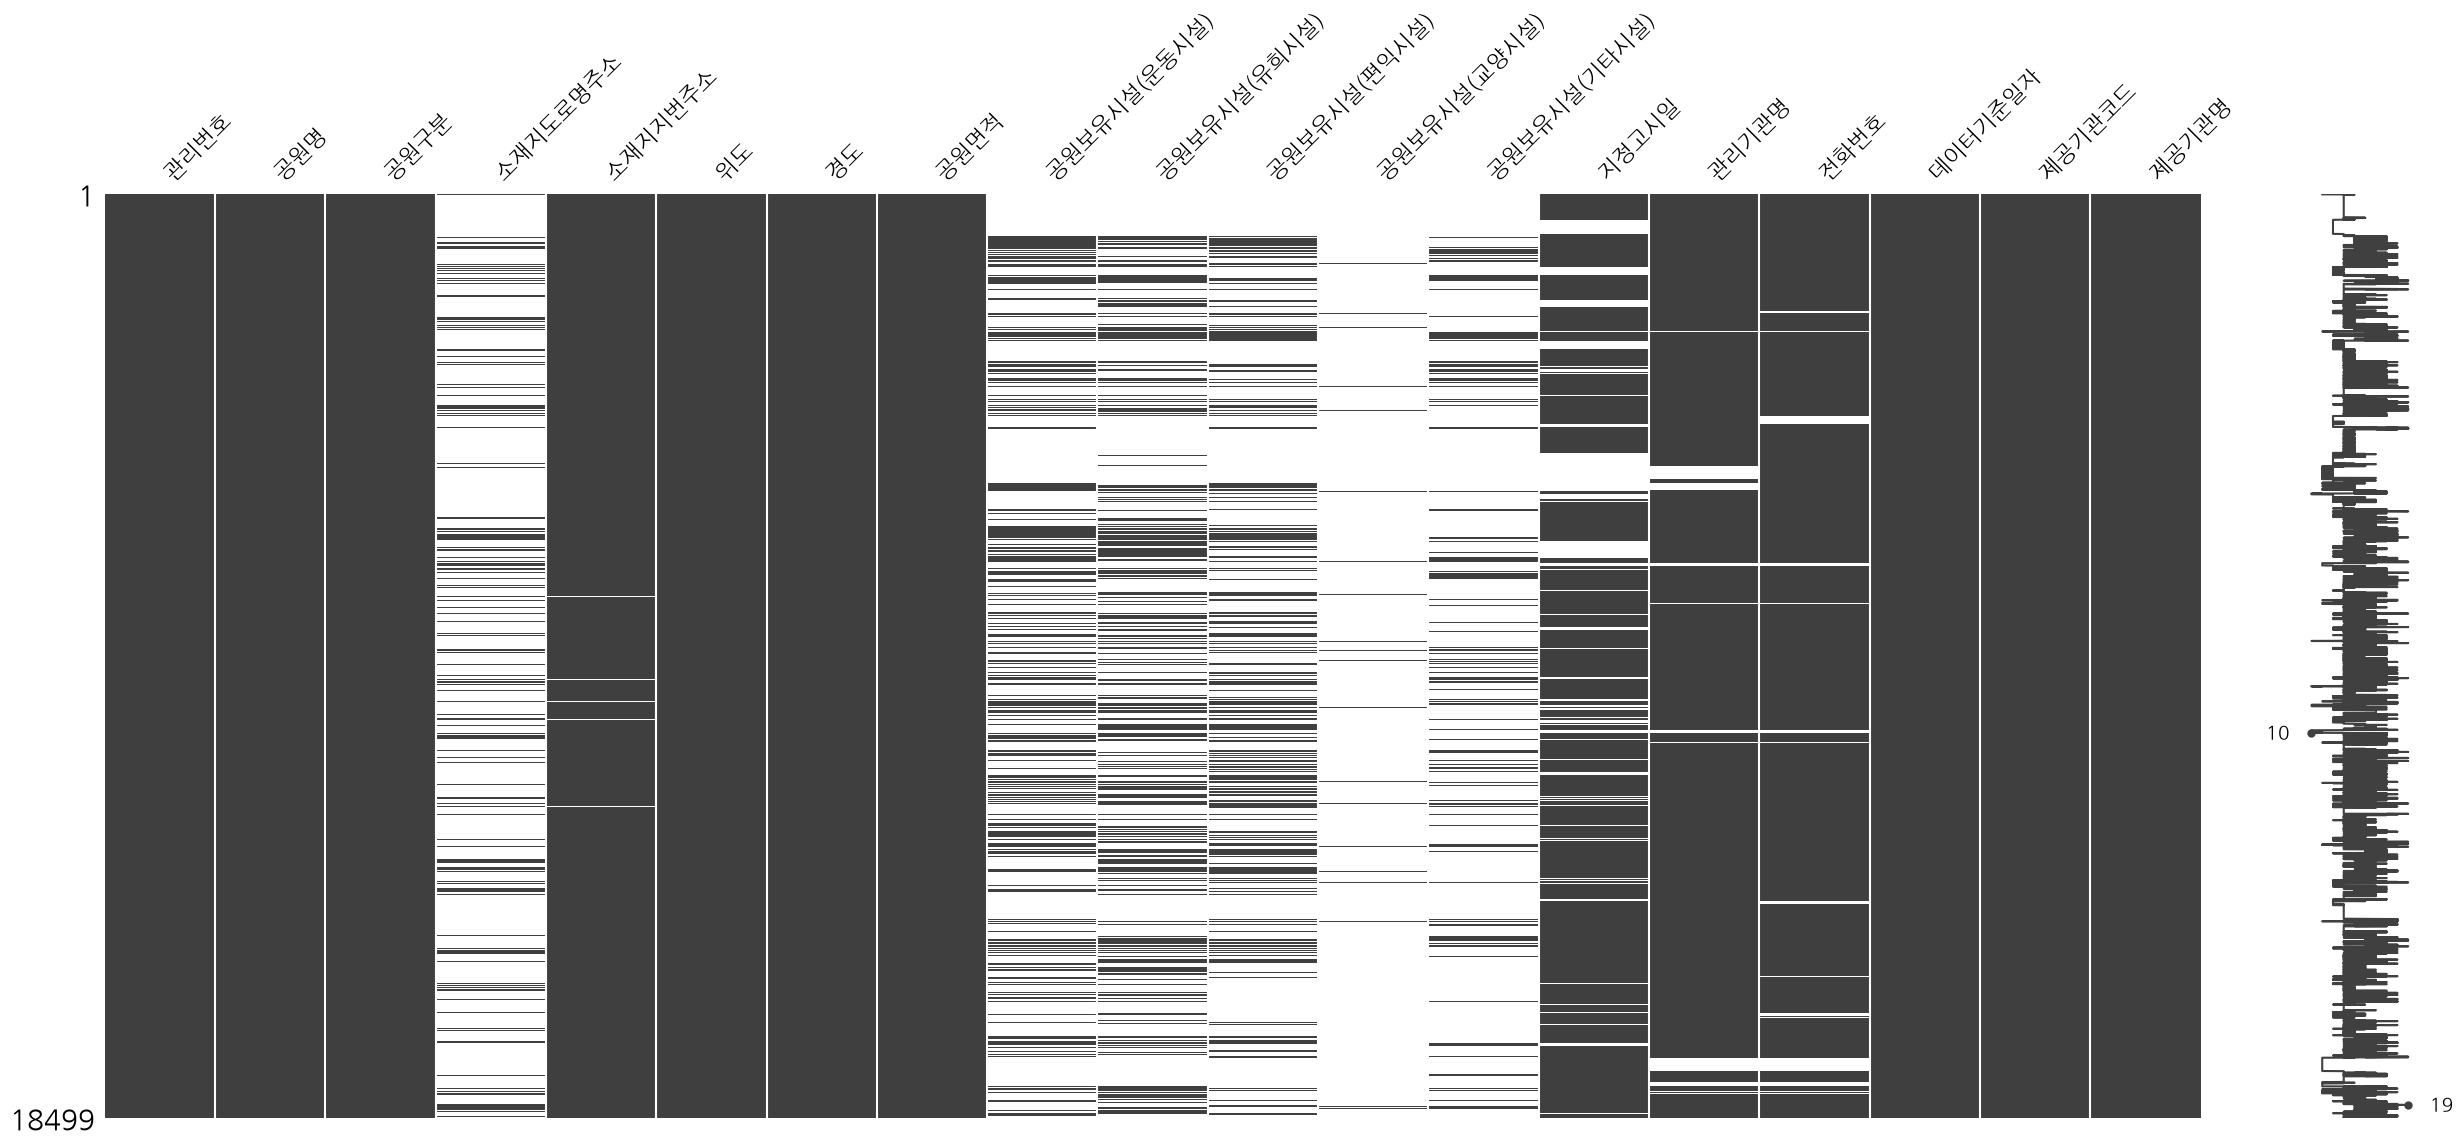

In [5]:
msno.matrix(park_202607_df, figsize=(30, 12))
plt.show()

관찰한 데이터에서 분석에 필요없는 데이터를 제거한다.

In [6]:
park_202607_df.columns

Index(['관리번호', '공원명', '공원구분', '소재지도로명주소', '소재지지번주소', '위도', '경도', '공원면적',
       '공원보유시설(운동시설)', '공원보유시설(유희시설)', '공원보유시설(편익시설)', '공원보유시설(교양시설)',
       '공원보유시설(기타시설)', '지정고시일', '관리기관명', '전화번호', '데이터기준일자', '제공기관코드', '제공기관명'],
      dtype='str')

In [7]:
# drop() 메소드로 불필요한 열을 제거한다. 열을 제거한 결과를 데이터프레임에 즉시 적용하려면 inplace=True 옵션을 지정한다.
park_202607_df.drop(columns=[
    '공원보유시설(운동시설)', '공원보유시설(유희시설)', '공원보유시설(편익시설)', '공원보유시설(교양시설)', '공원보유시설(기타시설)', '지정고시일', 
    '관리기관명', '전화번호', '데이터기준일자', '제공기관코드', '제공기관명'
])

,관리번호,공원명,공원구분,소재지도로명주소,소재지지번주소,위도,경도,공원면적
0,26200-00001,태종대유원지,기타,부산광역시 영도구 전망로 24,부산광역시 영도구 동삼동 산 19-2,35.059695,129.079806,1713763.0
1,26110-00001,용두산공원,근린공원,부산광역시 중구 용두산길 37-55,부산광역시 중구 광복동 2가 1-2,35.100209,129.032278,70812.0
2,29200-00028,월전공원,근린공원,-,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5
3,29140-00054,극락어린이공원,어린이공원,-,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3
4,29140-00053,서광어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2
...,...,...,...,...,...,...,...,...
18494,29110-00012,율곡,어린이공원,NaN,광주광역시 동구 산수동 708,35.159856,126.937268,4216.0
18495,29110-00044,천변,수변공원,NaN,광주광역시 동구 수기동 138,35.149929,126.909259,108420.0
18496,29110-00043,계림8,문화공원,광주광역시 동구 독립로 310 (계림동),광주광역시 동구 계림동 962,35.158152,126.913944,5999.0
18497,29110-00042,학동,역사공원,광주광역시 동구 천변우로 599 (학동),광주광역시 동구 학동 1013,35.131138,126.926317,2049.3


In [8]:
park_202607 = park_202607_df[['관리번호', '공원명', '공원구분', '소재지도로명주소', '소재지지번주소', '위도', '경도', '공원면적']]
# park_202607.columns = ['관리번호', '공원명', '공원구분', '도로명주소', '지번주소', '위도', '경도', '공원면적']
park_202607.rename(columns={'소재지도로명주소': '도로명주소', '소재지지번주소': '지번주소'}, inplace=True)
park_202607

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적
0,26200-00001,태종대유원지,기타,부산광역시 영도구 전망로 24,부산광역시 영도구 동삼동 산 19-2,35.059695,129.079806,1713763.0
1,26110-00001,용두산공원,근린공원,부산광역시 중구 용두산길 37-55,부산광역시 중구 광복동 2가 1-2,35.100209,129.032278,70812.0
2,29200-00028,월전공원,근린공원,-,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5
3,29140-00054,극락어린이공원,어린이공원,-,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3
4,29140-00053,서광어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2
...,...,...,...,...,...,...,...,...
18494,29110-00012,율곡,어린이공원,NaN,광주광역시 동구 산수동 708,35.159856,126.937268,4216.0
18495,29110-00044,천변,수변공원,NaN,광주광역시 동구 수기동 138,35.149929,126.909259,108420.0
18496,29110-00043,계림8,문화공원,광주광역시 동구 독립로 310 (계림동),광주광역시 동구 계림동 962,35.158152,126.913944,5999.0
18497,29110-00042,학동,역사공원,광주광역시 동구 천변우로 599 (학동),광주광역시 동구 학동 1013,35.131138,126.926317,2049.3


시각화를 통해 데이터 이상치 여부를 확인한다.

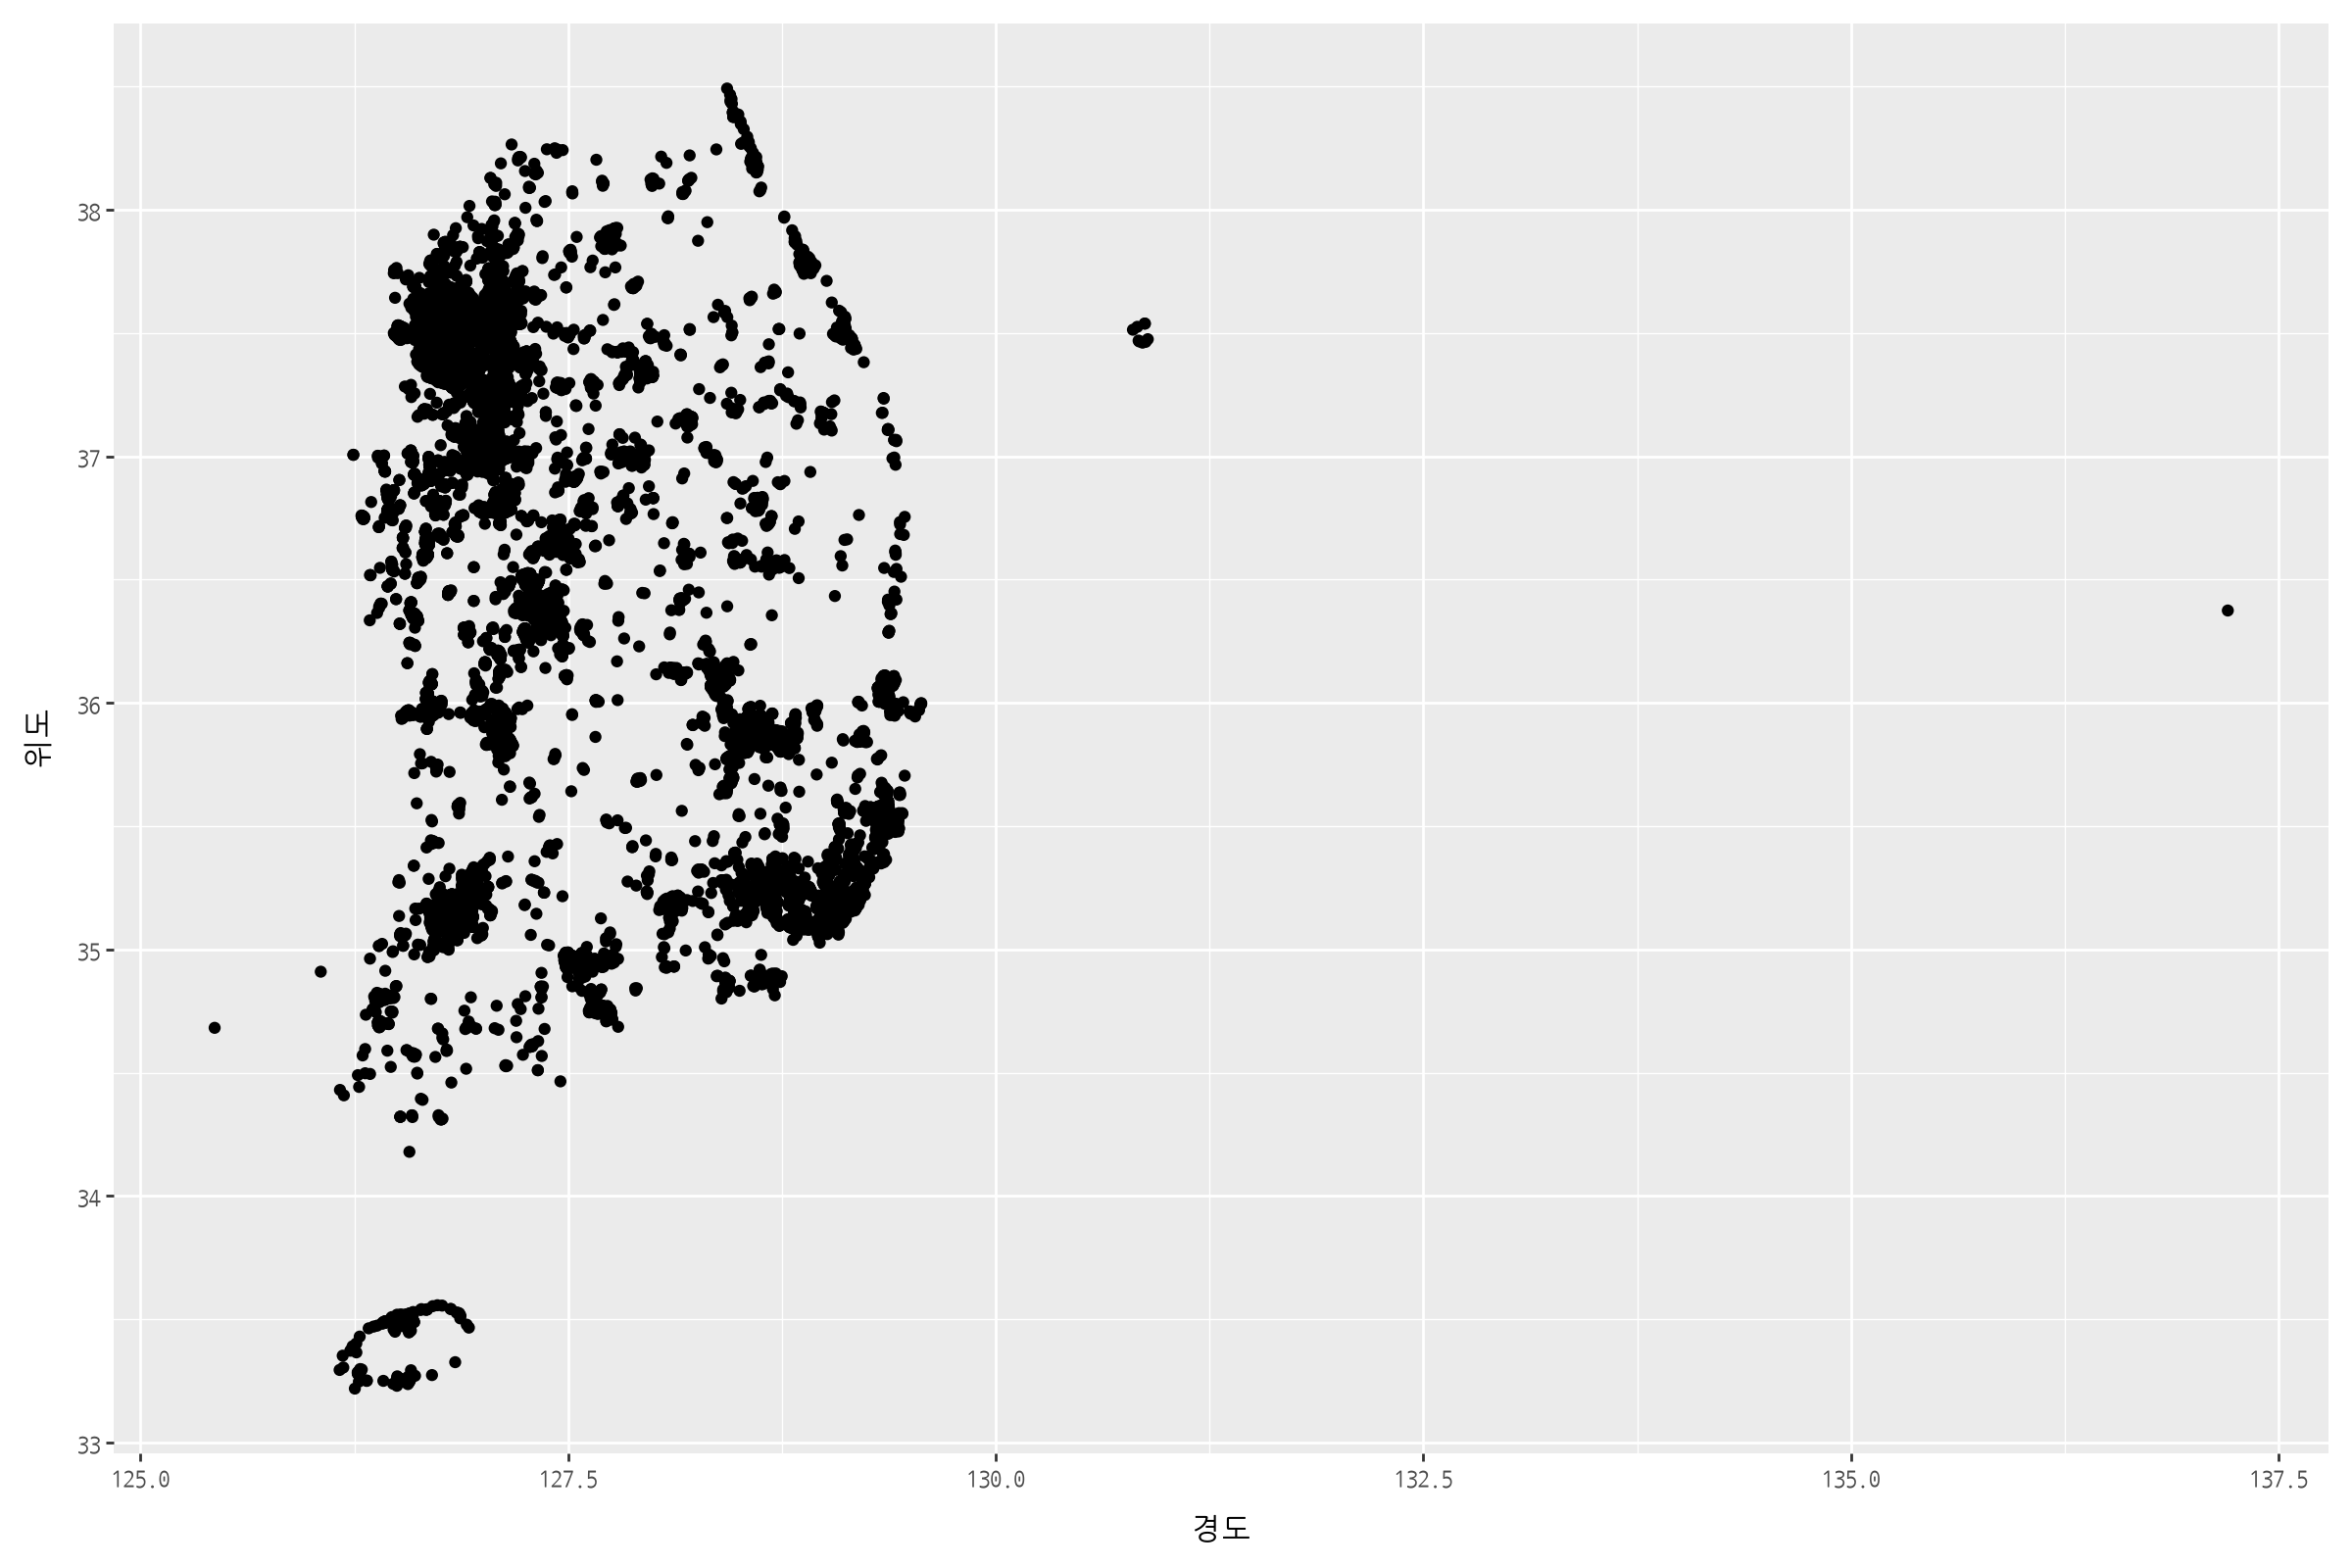

In [9]:
(
    ggplot(park_202607, aes(x='경도', y='위도'))
        + geom_point()
        + theme(text=element_text(family='NanumGothicCoding'), figure_size=(12, 8))
)

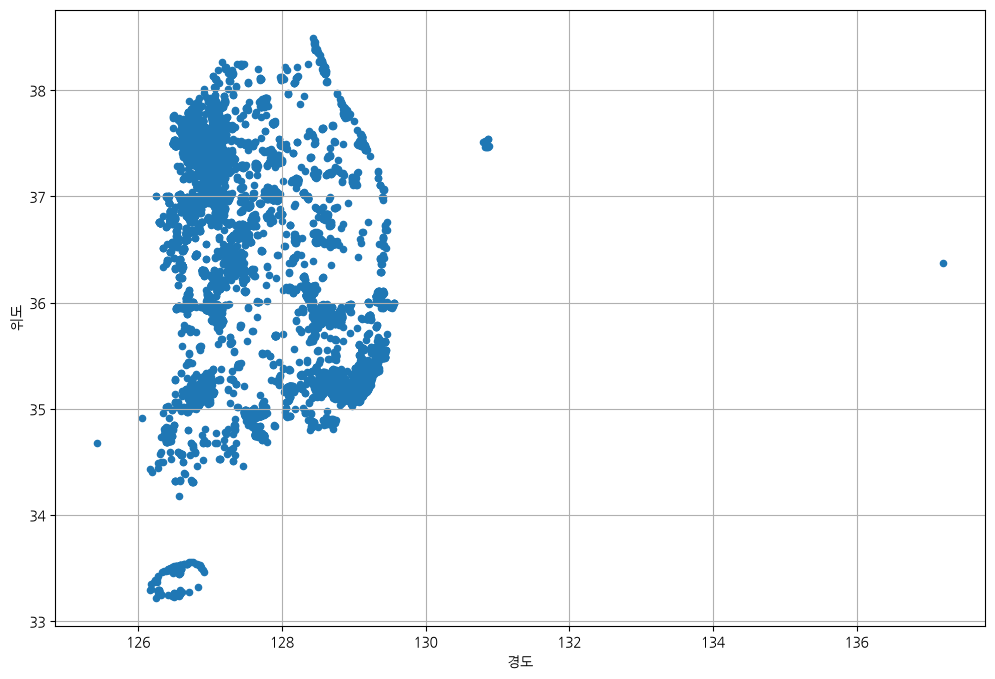

In [10]:
park_202607.plot.scatter(x='경도', y='위도', figsize=(12, 8), grid=True)
plt.show()

주소 전처리 => 도로명주소가 NaN이면 지번주소로 채운다.

In [11]:
# 도로명주소가 NaN인 데이터의 개수 => 지번주소만 입력된 데이터의 개수
# 도로명주소만 입력되고 지번주소가 입력되지 않은 데이터는 도로명주소 제도가 시행되고 난 이후에 조성된 공원이다.
park_202607.도로명주소.isna().sum()

np.int64(15359)

In [12]:
# 도로명주소는 입력되지 않고 지번주소만 입력된 데이터
# 불린 인덱싱 작업시 and 조건이나 or 조건이 사용되면 and, or연산에 참여하는 데이터에 관계 연산자(&, |)가 사용되면 논리식을 ()로 묶어준다.
# park_202607[(park_202607.도로명주소.isnull() == True) & (park_202607.지번주소.notnull() == True)]
# and, or 연산에 참여혀는 식 자체가 논리값이면 관계 연산자를 사용하지 않을 경우이므로 ()로 묶지않아도 된다.
park_202607[park_202607.도로명주소.isna() & park_202607.지번주소.notna()]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적
11,29200-00051,신가어린이공원,어린이공원,NaN,광주광역시 광산구 신가동 963-5,35.184617,126.832093,2845.9
12,29200-00050,가온어린이공원,어린이공원,NaN,광주광역시 광산구 신가동 961-2,35.185783,126.831980,2302.4
13,29200-00049,신가2공원,근린공원,NaN,광주광역시 광산구 신가동 1021-1,35.184814,126.841314,34409.1
14,29200-00047,뭉게뭉게어린이공원,어린이공원,NaN,광주광역시 광산구 운남동 776-5,35.177736,126.826486,1920.5
15,29155-00021,향등어린이공원,어린이공원,NaN,광주광역시 남구 행암동 504,35.100567,126.878852,1330.3
...,...,...,...,...,...,...,...,...
18492,29110-00014,용산,어린이공원,NaN,광주광역시 동구 용산동 670,35.117995,126.923116,1574.0
18493,29110-00013,월남,어린이공원,NaN,광주광역시 동구 월남동 623,35.103397,126.938209,1501.7
18494,29110-00012,율곡,어린이공원,NaN,광주광역시 동구 산수동 708,35.159856,126.937268,4216.0
18495,29110-00044,천변,수변공원,NaN,광주광역시 동구 수기동 138,35.149929,126.909259,108420.0


In [13]:
# 지번주소가 NaN인 데이터의 개수 => 도로명주소만 입력된 데이터의 개수
park_202607.지번주소.isna().sum()

np.int64(189)

In [14]:
# 도로명주소는 입력되고 지번주소가 입력되지 않은 데이터
park_202607[park_202607.도로명주소.notna() & park_202607.지번주소.isna()]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적
2978,41360-00078,별내택지어린이공원3,어린이공원,경기도 남양주시 별내3로 285,NaN,37.663214,127.117911,2743.00
3078,41360-00161,녹촌제1호소공원,소공원,경기도 남양주시 화도읍 경춘보학1길 7,NaN,37.650624,127.297329,1228.00
4082,44810-00027,내포8(거미줄놀이공원),어린이공원,충청남도 예산군 삽교읍 예목로 171,NaN,36.672245,126.685018,1841.00
4291,29200-00073,영산강대상,근린공원,광주광역시 광산구 첨단강변로 76,NaN,35.213304,126.852508,182906.72
4293,29200-00071,운남,근린공원,광주광역시 광산구 목련로 156,NaN,35.171441,126.815940,34212.80
...,...,...,...,...,...,...,...,...
18371,28260-00047,능내공원,근린공원,인천광역시 서구 검단로 540번길 41,NaN,37.601354,126.666897,77340.00
18390,51820-00027,도원3리 소공원,소공원,강원특별자치도 고성군 토성면 화원길 298,NaN,38.272362,128.522991,2000.00
18391,51820-00026,국회의정연수원 입구 소공원,소공원,강원특별자치도 고성군 토성면 진등3길 87,NaN,38.266912,128.510705,5000.00
18404,51820-00013,화포3거리 공원,소공원,강원특별자치도 고성군 거진읍 화진포길 204-25,NaN,38.466200,128.446402,500.00


In [15]:
# 도로명주소와 지번주소가 모두 입력된 데이터
park_202607[park_202607.도로명주소.notna() & park_202607.지번주소.notna()]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적
0,26200-00001,태종대유원지,기타,부산광역시 영도구 전망로 24,부산광역시 영도구 동삼동 산 19-2,35.059695,129.079806,1713763.0
1,26110-00001,용두산공원,근린공원,부산광역시 중구 용두산길 37-55,부산광역시 중구 광복동 2가 1-2,35.100209,129.032278,70812.0
2,29200-00028,월전공원,근린공원,-,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5
3,29140-00054,극락어린이공원,어린이공원,-,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3
4,29140-00053,서광어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2
...,...,...,...,...,...,...,...,...
18462,29110-00004,두암제2,근린공원,광주광역시 동구 갈마로 68 (산수동),광주광역시 동구 산수동 687,35.161588,126.937986,10000.6
18465,29110-00001,푸른길,근린공원,광주광역시 동구 제봉로 7 (학동),광주광역시 동구 학동 55-151,35.138933,126.921873,58205.8
18475,29110-00031,지원3-1,소공원,광주광역시 동구 소태길 31-12 (소태동),광주광역시 동구 소태동 230,35.121230,126.935738,596.0
18496,29110-00043,계림8,문화공원,광주광역시 동구 독립로 310 (계림동),광주광역시 동구 계림동 962,35.158152,126.913944,5999.0


In [16]:
# 도로명주소와 지번주소가 모두 입력되지 않은 데이터
park_202607[park_202607.도로명주소.isna() & park_202607.지번주소.isna()]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적


In [17]:
# 도로명주소에 입력된 '-'(이상치)를(경상북도 칠곡군) NaN으로 변경한다.
park_202607[park_202607.도로명주소 == '-']

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적
2,29200-00028,월전공원,근린공원,-,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5
3,29140-00054,극락어린이공원,어린이공원,-,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3
4,29140-00053,서광어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2
5,29140-00052,상일어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1344-6,35.159567,126.865175,2549.6
6,29140-00051,유촌어린이공원,어린이공원,-,광주광역시 서구 쌍촌동 1326-1,35.160866,126.857783,3733.4
7,29140-00050,상암공원,근린공원,-,광주광역시 서구 쌍촌동 1339,35.161571,126.863630,1462.0
8,29140-00049,무진푸른공원,근린공원,-,광주광역시 서구 쌍촌동 1337-1,35.161676,126.861421,9997.5
9,29140-00048,계수공원,근린공원,-,광주광역시 서구 쌍촌동 1313-1,35.161819,126.858515,8451.8
10,29140-00047,자연미소공원,근린공원,-,광주광역시 서구 유촌동 840-2,35.162057,126.854186,5756.0


In [18]:
park_202607.loc[park_202607.도로명주소 == '-', '도로명주소'] = np.nan

주소의 오타를 수정한다.

In [19]:
park_202607['도로명주소'] = park_202607.도로명주소.str.replace('인천광역시연수구 컨벤시아대로 160', '인천광역시 연수구 컨벤시아대로 160')
park_202607['지번주소'] = park_202607.지번주소.str.replace('경개도 포천시 일동면 기산리 287-28', '경기도 포천시 일동면 기산리 287-28')

park_202607['지번주소'] = park_202607.지번주소.str.replace('서울특별시 강서구마곡동 790-6', '서울특별시 강서구 마곡동 790-6')
park_202607['지번주소'] = park_202607.지번주소.str.replace('서울특별시 강서구마곡동 800-7', '서울특별시 강서구 마곡동 800-7')
park_202607['지번주소'] = park_202607.지번주소.str.replace('서울특별시 강서구염창동 306-1', '서울특별시 강서구 염창동 306-1')
park_202607['지번주소'] = park_202607.지번주소.str.replace('서울특별시 강서구염창동 309-1', '서울특별시 강서구 염창동 309-1')
park_202607['지번주소'] = park_202607.지번주소.str.replace('서울특별시 강서구가양동 1499', '서울특별시 강서구 가양동 1499')

In [20]:
# 도로명주소가 NaN인 데이터를 지번주소로 채운다.
park_202607['도로명주소'] = park_202607.도로명주소.fillna(park_202607.지번주소)
park_202607.도로명주소.isnull().sum()

np.int64(0)

도로명주소에서 공백을 경계로 분리해서 파생 변수로 추가한다.

In [21]:
# split() 메소드 실행시 expand=True 옵션을 지정하면 구분자를 경계로 분리된 결과가 데이터프레임으로 만들어진다.
park_202607.도로명주소.str.split(' ', expand=True)

,0,1,2,3,4,5,6,7,8
0,부산광역시,영도구,전망로,24,NaN,NaN,NaN,NaN,NaN
1,부산광역시,중구,용두산길,37-55,NaN,NaN,NaN,NaN,NaN
2,광주광역시,광산구,장록동,751-1,NaN,NaN,NaN,NaN,NaN
3,광주광역시,서구,유촌동,857,NaN,NaN,NaN,NaN,NaN
4,광주광역시,서구,쌍촌동,1358,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
18494,광주광역시,동구,산수동,708,NaN,NaN,NaN,NaN,NaN
18495,광주광역시,동구,수기동,138,NaN,NaN,NaN,NaN,NaN
18496,광주광역시,동구,독립로,310,(계림동),NaN,NaN,NaN,NaN
18497,광주광역시,동구,천변우로,599,(학동),NaN,NaN,NaN,NaN


In [22]:
park_202607['주소1'] = park_202607.도로명주소.str.split(' ', expand=True)[0]
park_202607['주소2'] = park_202607.도로명주소.str.split(' ', expand=True)[1]
park_202607['주소3'] = park_202607.도로명주소.str.split(' ', expand=True)[2]
park_202607['주소4'] = park_202607.도로명주소.str.split(' ', expand=True)[3]
park_202607

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4
0,26200-00001,태종대유원지,기타,부산광역시 영도구 전망로 24,부산광역시 영도구 동삼동 산 19-2,35.059695,129.079806,1713763.0,부산광역시,영도구,전망로,24
1,26110-00001,용두산공원,근린공원,부산광역시 중구 용두산길 37-55,부산광역시 중구 광복동 2가 1-2,35.100209,129.032278,70812.0,부산광역시,중구,용두산길,37-55
2,29200-00028,월전공원,근린공원,광주광역시 광산구 장록동 751-1,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5,광주광역시,광산구,장록동,751-1
3,29140-00054,극락어린이공원,어린이공원,광주광역시 서구 유촌동 857,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3,광주광역시,서구,유촌동,857
4,29140-00053,서광어린이공원,어린이공원,광주광역시 서구 쌍촌동 1358,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2,광주광역시,서구,쌍촌동,1358
...,...,...,...,...,...,...,...,...,...,...,...,...
18494,29110-00012,율곡,어린이공원,광주광역시 동구 산수동 708,광주광역시 동구 산수동 708,35.159856,126.937268,4216.0,광주광역시,동구,산수동,708
18495,29110-00044,천변,수변공원,광주광역시 동구 수기동 138,광주광역시 동구 수기동 138,35.149929,126.909259,108420.0,광주광역시,동구,수기동,138
18496,29110-00043,계림8,문화공원,광주광역시 동구 독립로 310 (계림동),광주광역시 동구 계림동 962,35.158152,126.913944,5999.0,광주광역시,동구,독립로,310
18497,29110-00042,학동,역사공원,광주광역시 동구 천변우로 599 (학동),광주광역시 동구 학동 1013,35.131138,126.926317,2049.3,광주광역시,동구,천변우로,599


대한민국 영토 범위를 벗어난 위도, 경도와 입력되지 않은 위도, 경도를 찾아 처리한다.

In [23]:
park_202607[['위도', '경도']].describe()

,위도,경도
count,18499.000000,18499.000000
mean,36.502789,127.469601
std,1.029747,0.847369
min,33.218571,125.433012
25%,35.558629,126.864257
50%,36.785392,127.104036
75%,37.433572,128.082836
max,38.491242,137.202661


In [24]:
# 위도와 경도가 대한민국 영토 범위를 벗어난 데터를 추출한다.
park_202607[(park_202607.위도 < 33.111944) | (park_202607.위도 > 38.611111) | (park_202607.경도 < 124.662500) | (park_202607.경도 > 131.872778)]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4
14355,43113-00080,근린공원5(만수공원),근린공원,충청북도 청주시 흥덕구 오송읍 만수리 512,충청북도 청주시 흥덕구 오송읍 만수리 512,36.374204,137.202661,33258.0,충청북도,청주시,흥덕구,오송읍


In [25]:
# 근린공원5(만수공원): 36.374204, 137.202661 => 36.63179048, 127.33252872
park_202607.loc[14355, '경도'] = 127.33252872

In [26]:
park_202607[(park_202607.위도 < 33.111944) | (park_202607.위도 > 38.611111) | (park_202607.경도 < 124.662500) | (park_202607.경도 > 131.872778)]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4


In [27]:
# 위도와 경도가 입력되지 않은 데이터를 추출한다.
park_202607[park_202607.위도.isnull() | park_202607.경도.isna()]

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4


주소 전처리

In [28]:
# '주소1'열이 '강원도'인 데이터를 '강원특별자치도'로 수정한다.
park_202607['주소1'] = park_202607.주소1.str.replace('강원도', '강원특별자치도')
# '주소1'열이 '전라북도'인 데이터를 '전북특별자치도'로 수정한다.
park_202607['주소1'] = park_202607.주소1.str.replace('전라북도', '전북특별자치도')
# 2026년 7월 1일부로 '전라남도'와 '광주광역시'가 통합되서 '전남광주통합특별시'가 되었으므로 '주소1'열이 '전라북도'인 데이터와 '광주광역시'인 데이터를 
# '전남광주통합특별시'로 수정한다.
park_202607['주소1'] = park_202607.주소1.str.replace('전라남도', '전남광주통합특별시')
park_202607['주소1'] = park_202607.주소1.str.replace('광주광역시', '전남광주통합특별시')

In [29]:
# value_counts() 메소드를 실행하면 시리즈의 데이터중에서 같은 값들의 개수를 센다.
park_202607.주소1.value_counts()

주소1
경기도          4734
전남광주통합특별시    1992
서울특별시        1786
충청남도         1740
경상남도         1346
경상북도         1066
인천광역시         814
충청북도          800
강원특별자치도       768
부산광역시         713
대구광역시         657
전북특별자치도       653
울산광역시         495
대전광역시         465
제주특별자치도       271
세종특별자치시       199
Name: count, dtype: int64

In [30]:
park_202607.to_csv('./data/park_202607_ok.csv')

시도별 공원 데이터 시각화

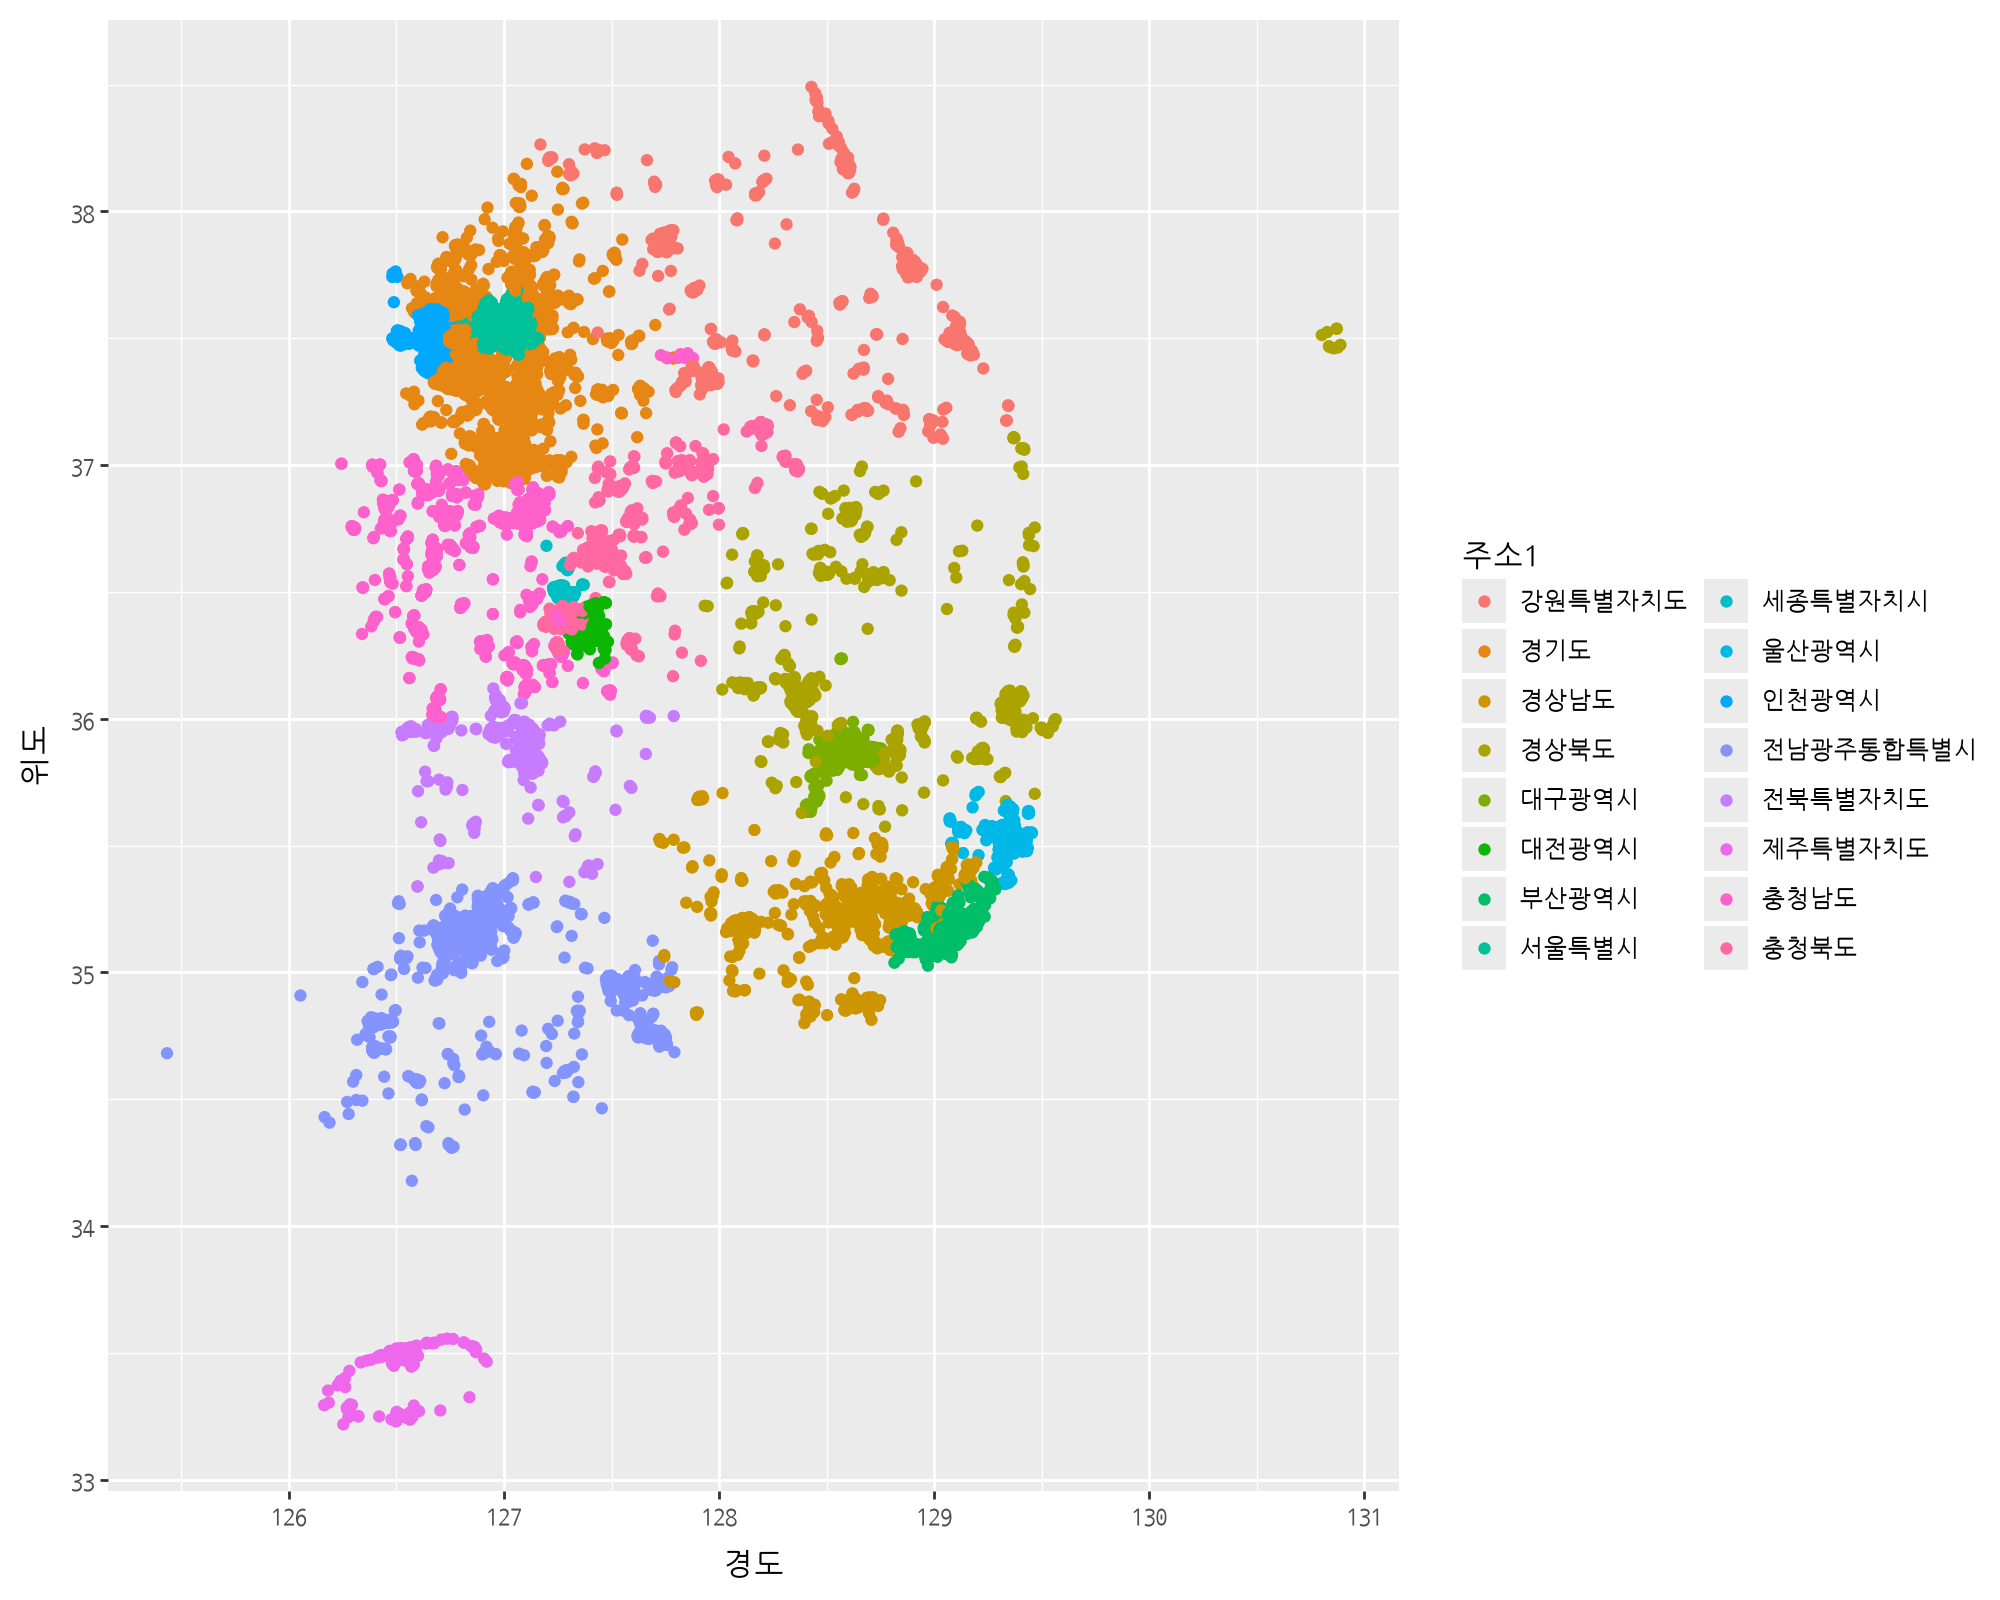

In [31]:
(
    ggplot(park_202607, aes(x='경도', y='위도', color='주소1'))
        + geom_point()
        + theme(text=element_text(family='NanumGothicCoding'), figure_size=(10, 8))
)

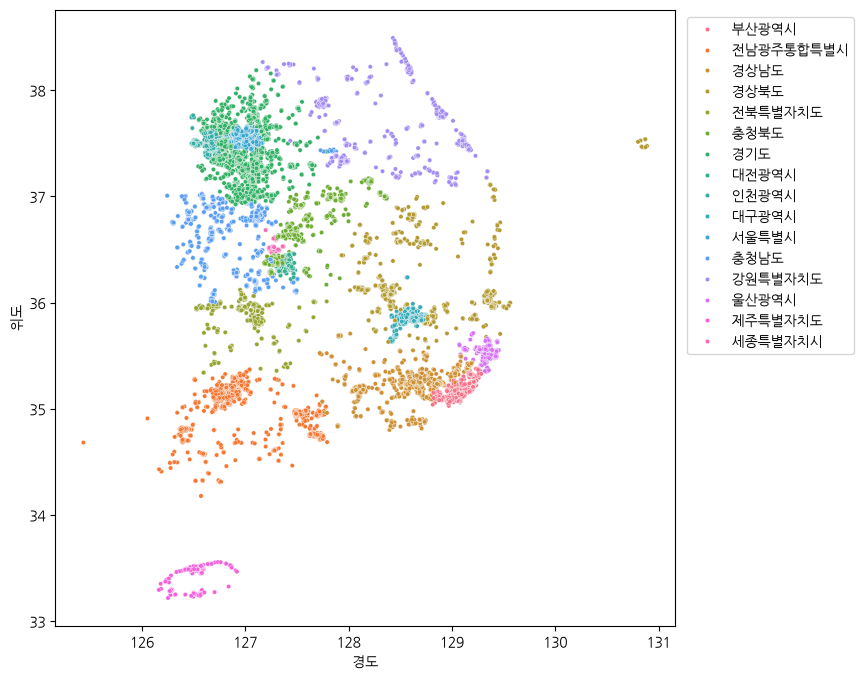

In [32]:
plt.figure(figsize=(8, 8))
sns.scatterplot(park_202607, x='경도', y='위도', s=10, hue='주소1')
plt.legend(loc=1, bbox_to_anchor=(1.3, 1))
plt.show()

공원 구분변 분포현황 시각화

In [33]:
# park_202607['공원구분'] = park_202607.공원구분.str.replace('기타공원', '기타')
park_202607.loc[park_202607.공원구분 == '기타공원', '공원구분'] = '기타'
park_202607.loc[park_202607.공원구분 == '주제공원', '공원구분'] = '문화공원'
park_202607.loc[park_202607.공원구분 == '마을마당', '공원구분'] = '어린이공원'
park_202607.loc[park_202607.공원구분 == '가로공원', '공원구분'] = '기타'
park_202607.loc[park_202607.공원구분 == '도시농업공원', '공원구분'] = '기타'

In [34]:
park_202607.공원구분.value_counts()

공원구분
어린이공원    9302
근린공원     4112
소공원      3105
기타        578
문화공원      485
수변공원      405
체육공원      269
역사공원      204
묘지공원       39
Name: count, dtype: int64

In [35]:
# '공원면적' 열에 적당한 수식을 실행해서 '공원면적비율'이라는 파생 변수를 추가한다.
# 시리즈에 저장된 데이터가 lambda 뒤의 변수로 1건씩 차례대로 전달되고 ':' 뒤의 수식을 실행한 후 apply() 메소드에 의해서 시리즈에 일괄 적용된다.
# 시리즈.apply(lambda 변수: 변수를 포함한 수식)
park_202607['공원면적비율'] = park_202607.공원면적.apply(lambda x: np.sqrt(x) * 0.01)
park_202607

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4,공원면적비율
0,26200-00001,태종대유원지,기타,부산광역시 영도구 전망로 24,부산광역시 영도구 동삼동 산 19-2,35.059695,129.079806,1713763.0,부산광역시,영도구,전망로,24,13.091077
1,26110-00001,용두산공원,근린공원,부산광역시 중구 용두산길 37-55,부산광역시 중구 광복동 2가 1-2,35.100209,129.032278,70812.0,부산광역시,중구,용두산길,37-55,2.661052
2,29200-00028,월전공원,근린공원,광주광역시 광산구 장록동 751-1,광주광역시 광산구 장록동 751-1,35.132211,126.768588,40038.5,전남광주통합특별시,광산구,장록동,751-1,2.000962
3,29140-00054,극락어린이공원,어린이공원,광주광역시 서구 유촌동 857,광주광역시 서구 유촌동 857,35.165298,126.858437,1643.3,전남광주통합특별시,서구,유촌동,857,0.405376
4,29140-00053,서광어린이공원,어린이공원,광주광역시 서구 쌍촌동 1358,광주광역시 서구 쌍촌동 1358,35.157193,126.864497,3067.2,전남광주통합특별시,서구,쌍촌동,1358,0.553823
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18494,29110-00012,율곡,어린이공원,광주광역시 동구 산수동 708,광주광역시 동구 산수동 708,35.159856,126.937268,4216.0,전남광주통합특별시,동구,산수동,708,0.649307
18495,29110-00044,천변,수변공원,광주광역시 동구 수기동 138,광주광역시 동구 수기동 138,35.149929,126.909259,108420.0,전남광주통합특별시,동구,수기동,138,3.292719
18496,29110-00043,계림8,문화공원,광주광역시 동구 독립로 310 (계림동),광주광역시 동구 계림동 962,35.158152,126.913944,5999.0,전남광주통합특별시,동구,독립로,310,0.774532
18497,29110-00042,학동,역사공원,광주광역시 동구 천변우로 599 (학동),광주광역시 동구 학동 1013,35.131138,126.926317,2049.3,전남광주통합특별시,동구,천변우로,599,0.452692


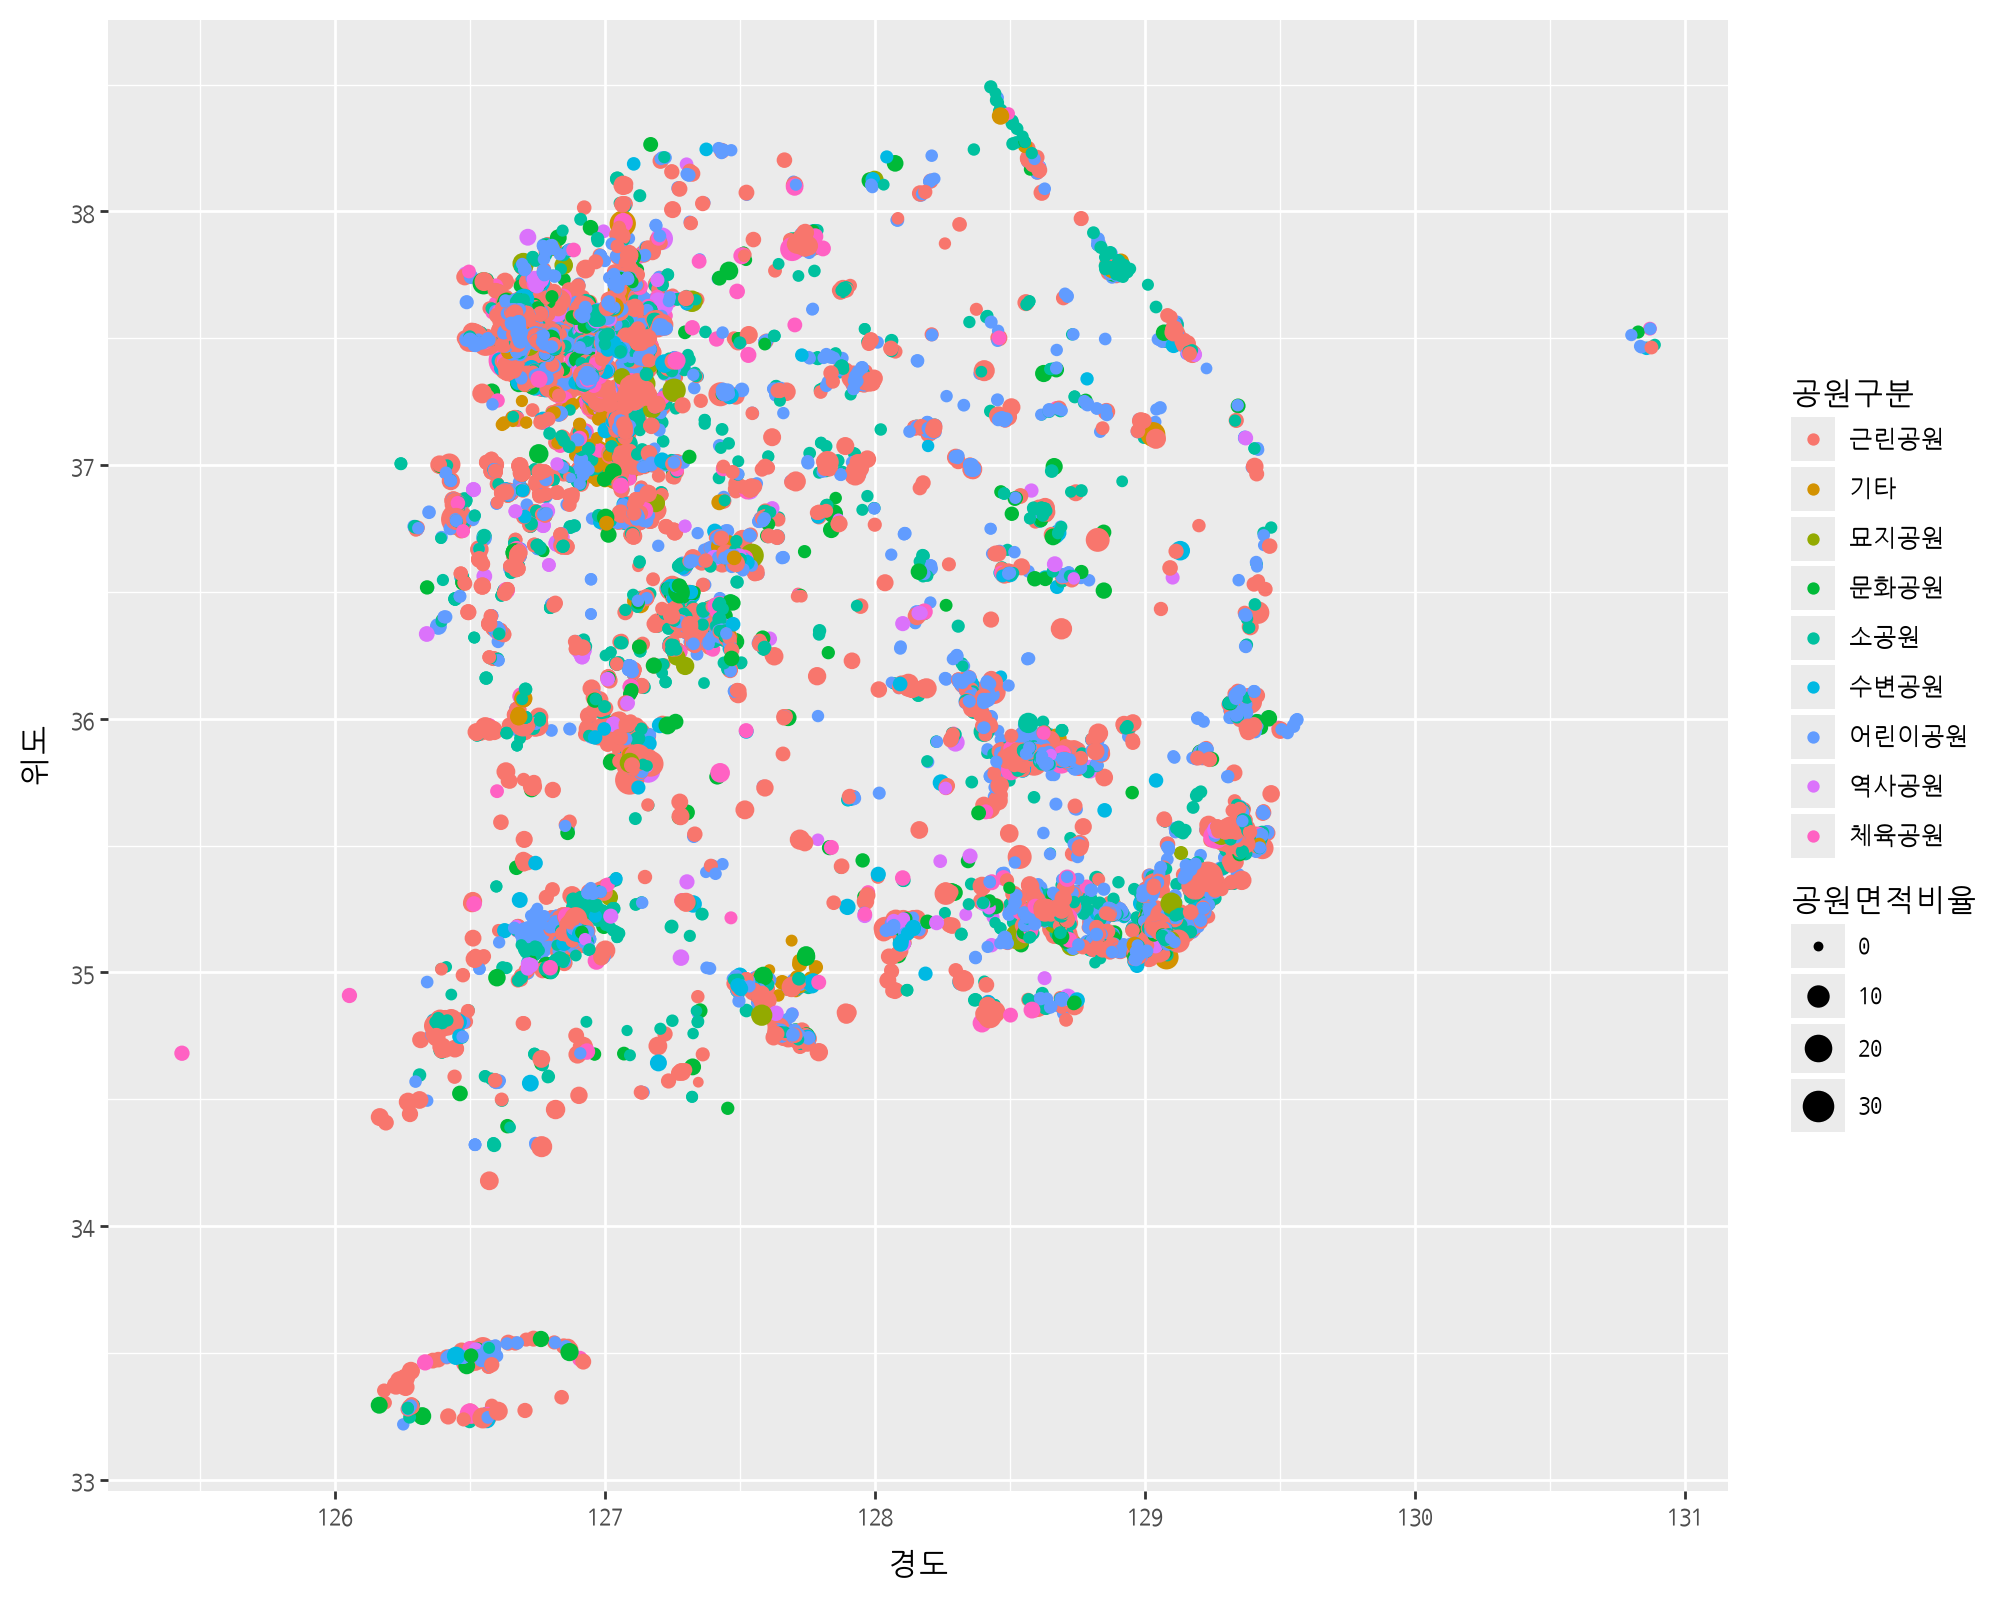

In [36]:
(
    ggplot(park_202607, aes(x='경도', y='위도', color='공원구분', size='공원면적비율'))
        + geom_point()
        + theme(text=element_text(family='NanumGothicCoding'), figure_size=(10, 8))
)

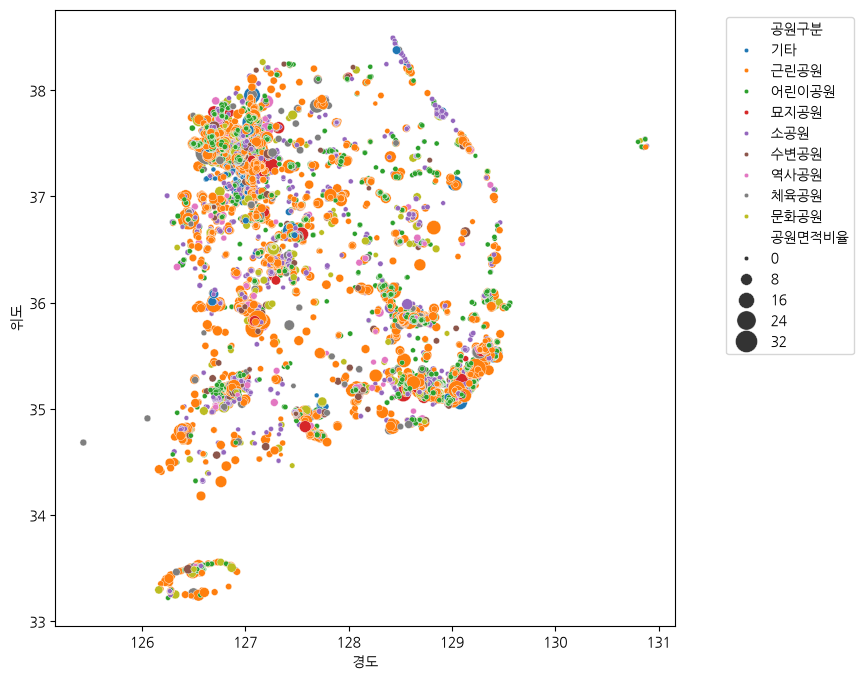

In [37]:
plt.figure(figsize=(8, 8))
sns.scatterplot(park_202607, x='경도', y='위도', s=10, hue='공원구분', size='공원면적비율', sizes=(10, 300))
plt.legend(loc=1, bbox_to_anchor=(1.3, 1))
plt.show()

어린이공원을 제외한 공원 구분별 분포현황 시각화

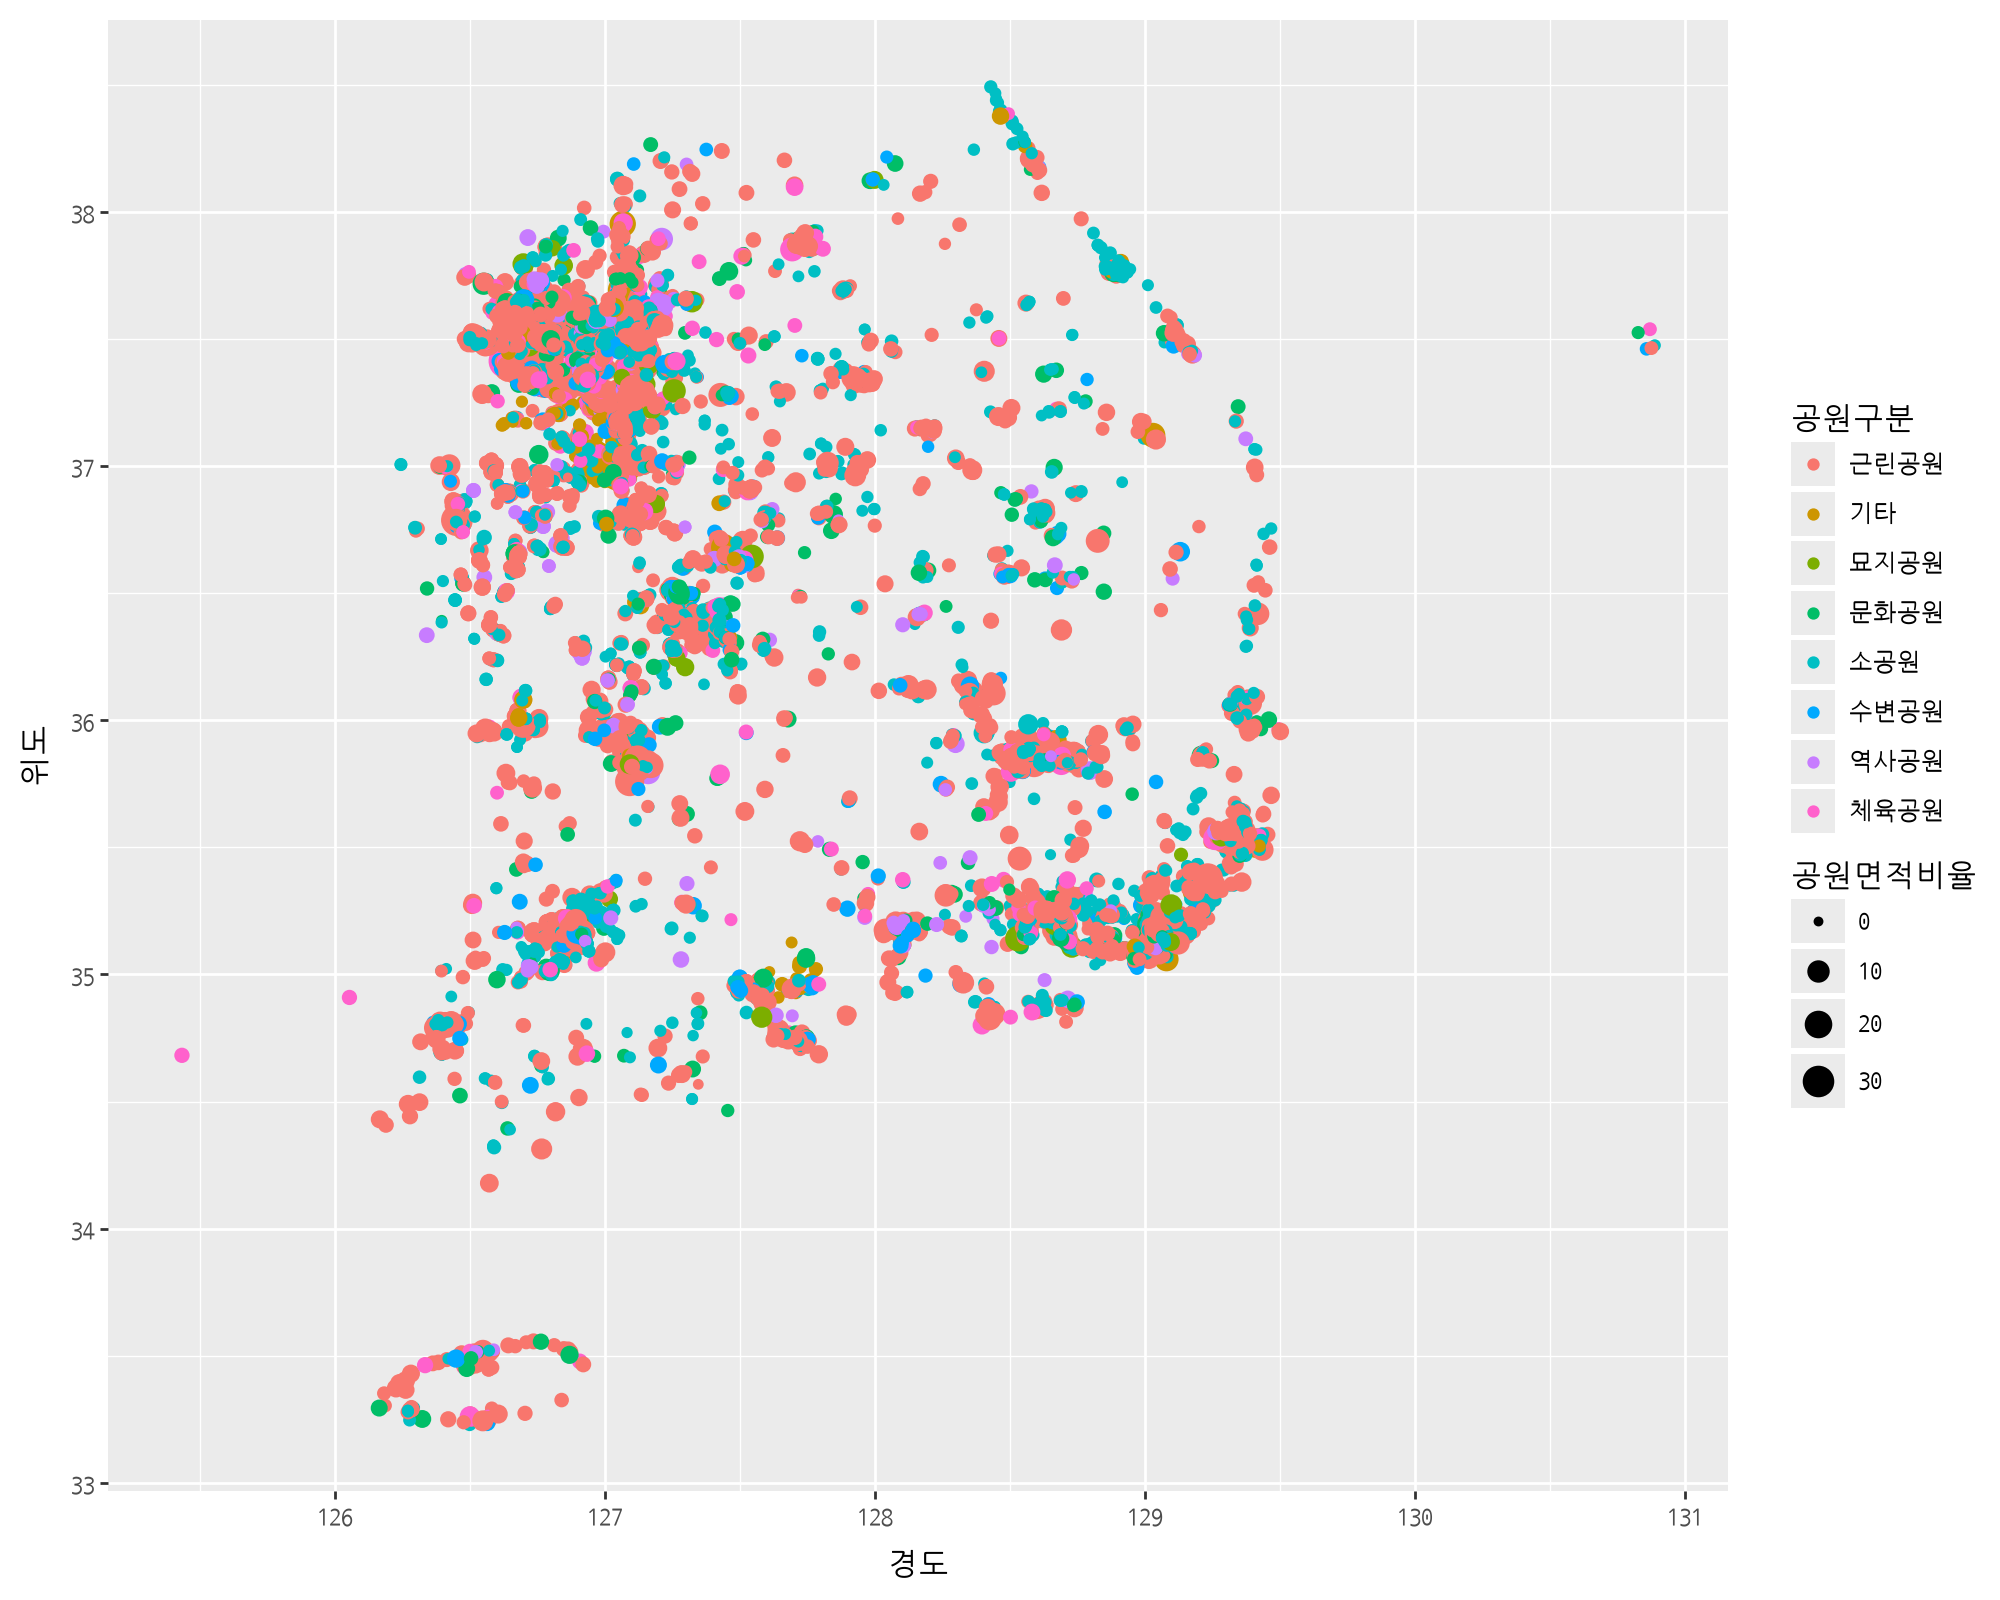

In [38]:
(
    ggplot(park_202607[park_202607.공원구분 != '어린이공원'], aes(x='경도', y='위도', color='공원구분', size='공원면적비율'))
        + geom_point()
        + theme(text=element_text(family='NanumGothicCoding'), figure_size=(10, 8))
)

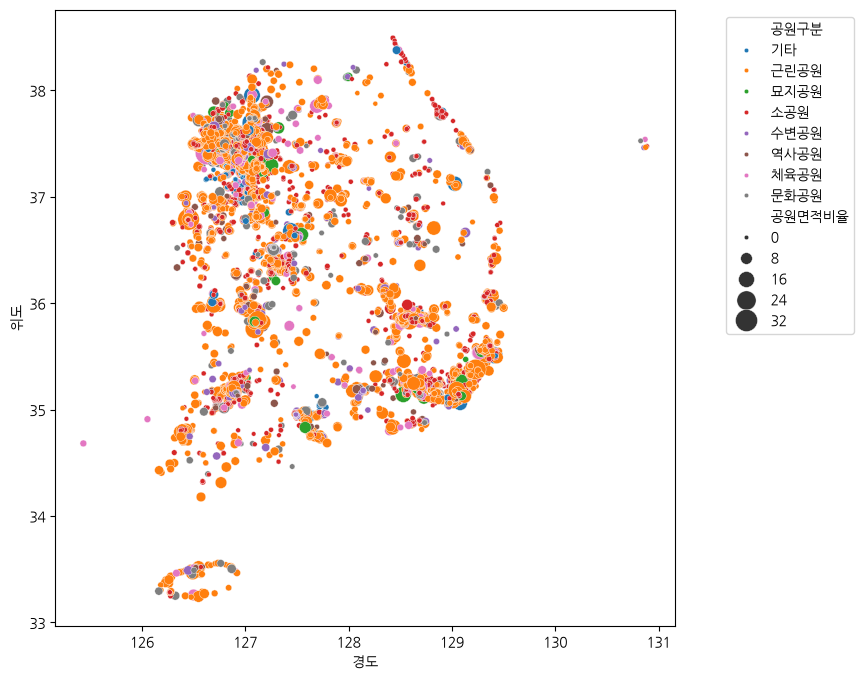

In [39]:
plt.figure(figsize=(8, 8))
sns.scatterplot(park_202607[park_202607.공원구분 != '어린이공원'], x='경도', y='위도', s=10, hue='공원구분', size='공원면적비율', sizes=(10, 300))
plt.legend(loc=1, bbox_to_anchor=(1.3, 1))
plt.show()

시도별 공원 시각화

value_counts() 메소드는 지정된 시리즈에 저장된 데이터별 개수 또는 전체 개수에 대한 비율을 계산한다.  
normalize 속성의 기본값은 False로 개수를 계산하고 True로 지정하면 전체 개수에 대한 비율을 계산한다.  
ascending 속성의 기본값은 False로 계산 결과를 내림차순 정렬하고 True로 지정하면 오름차순 정렬한다.  
dropna 속성의 기본값은 True로 NaN을 무시하고 계산하고 False로 지정하면 NaN을 포함시켜 계산한다.

In [40]:
park_count = pd.DataFrame(park_202607.주소1.value_counts()) # normalize=False, ascending=False, dropna=True
park_count.head()

,count
주소1,
경기도,4734
전남광주통합특별시,1992
서울특별시,1786
충청남도,1740
경상남도,1346


In [41]:
park_per = pd.DataFrame(park_202607.주소1.value_counts(normalize=True))
park_per.head()

,proportion
주소1,
경기도,0.255906
전남광주통합특별시,0.107681
서울특별시,0.096546
충청남도,0.094059
경상남도,0.072761


In [42]:
pd.DataFrame(park_202607.주소1.value_counts(ascending=True)).head()

,count
주소1,
세종특별자치시,199
제주특별자치도,271
대전광역시,465
울산광역시,495
전북특별자치도,653


In [43]:
pd.DataFrame(park_202607.주소1.value_counts(dropna=False)).head()

,count
주소1,
경기도,4734
전남광주통합특별시,1992
서울특별시,1786
충청남도,1740
경상남도,1346


시도별 공원 개수 데이터와 전체 개수에 대한 비율 데이터를 병합한다.

concat() 메소드를 이용해서 데이터프레임을 아래로 붙일때는 axis를 생략하거 0으로 지정하고 옆으로 붙일때는 1로 지정한다.  
concat() 메소드를 실행한 결과에 reset_index() 메소드를 실행하면 기존 인덱스가 데이터화되고 새 인덱스가 부여된다.

In [44]:
park_sido = pd.concat([park_count, park_per], axis=1).reset_index()
park_sido.columns = ['시도', '개수', '비율']
park_sido.head()

,시도,개수,비율
0,경기도,4734,0.255906
1,전남광주통합특별시,1992,0.107681
2,서울특별시,1786,0.096546
3,충청남도,1740,0.094059
4,경상남도,1346,0.072761


merge() 메소드로 두 데이터프레임을 병합할 때 왼쪽, 오른쪽 데이터프레임에 공통된(병합의 기준이 되는) 데이터가 있는 열 이름을 left_on, right_on 속성으로 지정한다.  
공통된 열 이름이 없을 경우 병합 기준을 인덱스로 지정하려면 left_index, right_index 속성을 각각 True로 지정하면 된다.  
merge() 메소드도 concat() 메소드와 같이 실행한 결과에 reset_index() 메소드를 실행하면 기존 인덱스가 데이터화되고 새 인덱스가 부여된다.

In [45]:
# park_sido = park_count.merge(park_per, left_on='주소1', right_on='주소1', how='inner')
park_sido = park_count.merge(park_per, left_index=True, right_index=True).reset_index()
park_sido.columns = ['시도', '개수', '비율']
park_sido.head()

,시도,개수,비율
0,경기도,4734,0.255906
1,전남광주통합특별시,1992,0.107681
2,서울특별시,1786,0.096546
3,충청남도,1740,0.094059
4,경상남도,1346,0.072761


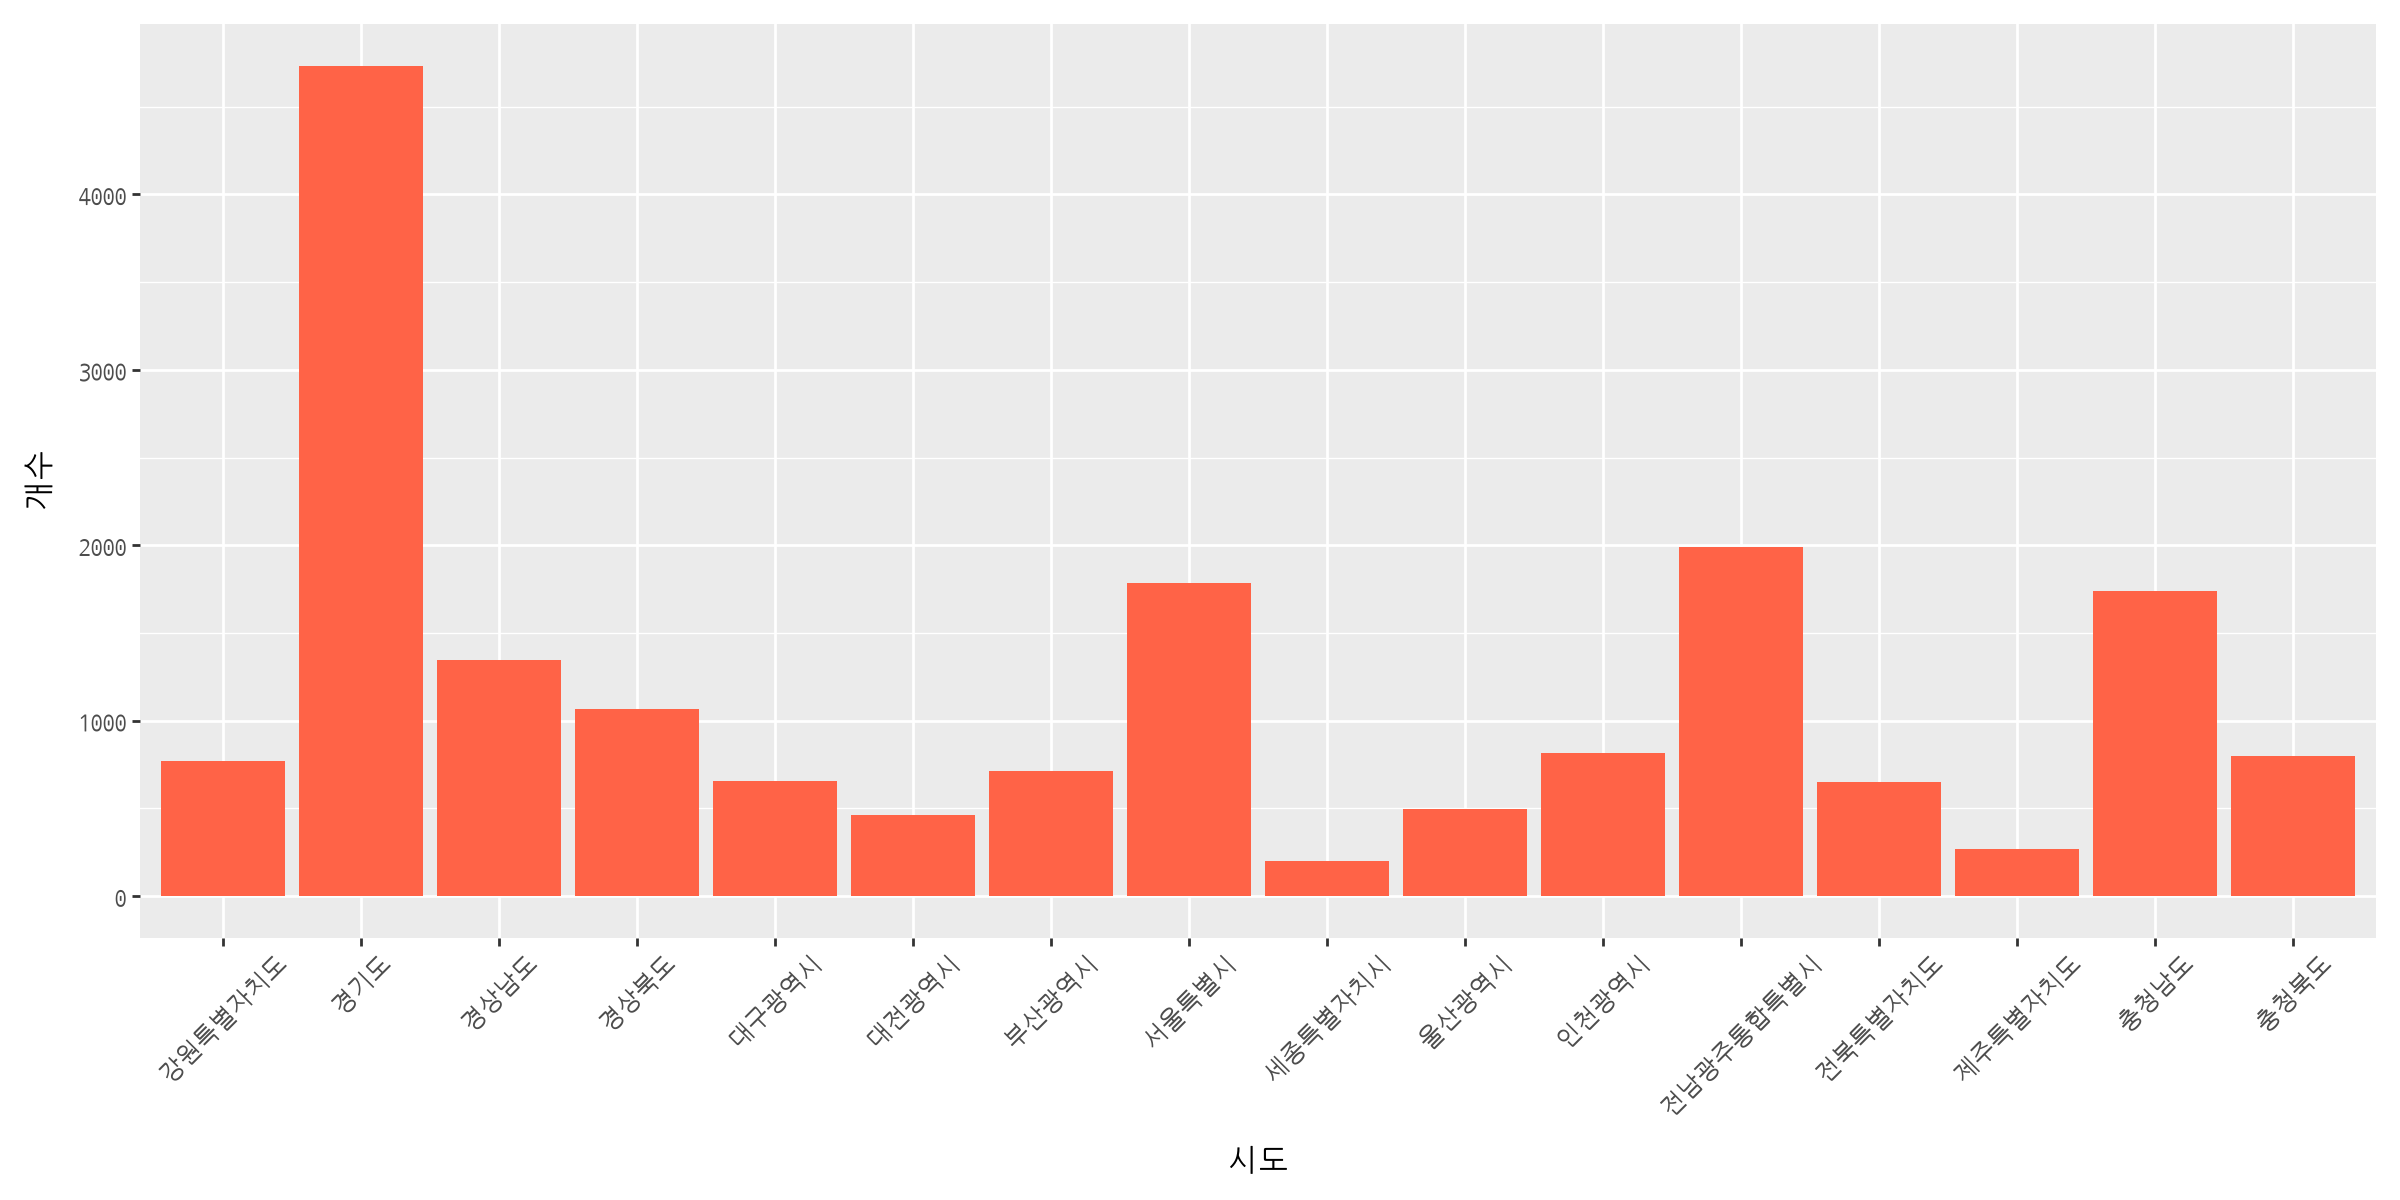

In [46]:
(
    ggplot(park_sido, aes(x='시도', y='개수'))
        + geom_bar(stat='identity', position='dodge', fill='tomato')
        + theme(text=element_text(family='NanumGothicCoding'), figure_size=(12, 6), axis_text_x=element_text(rotation=45))
)

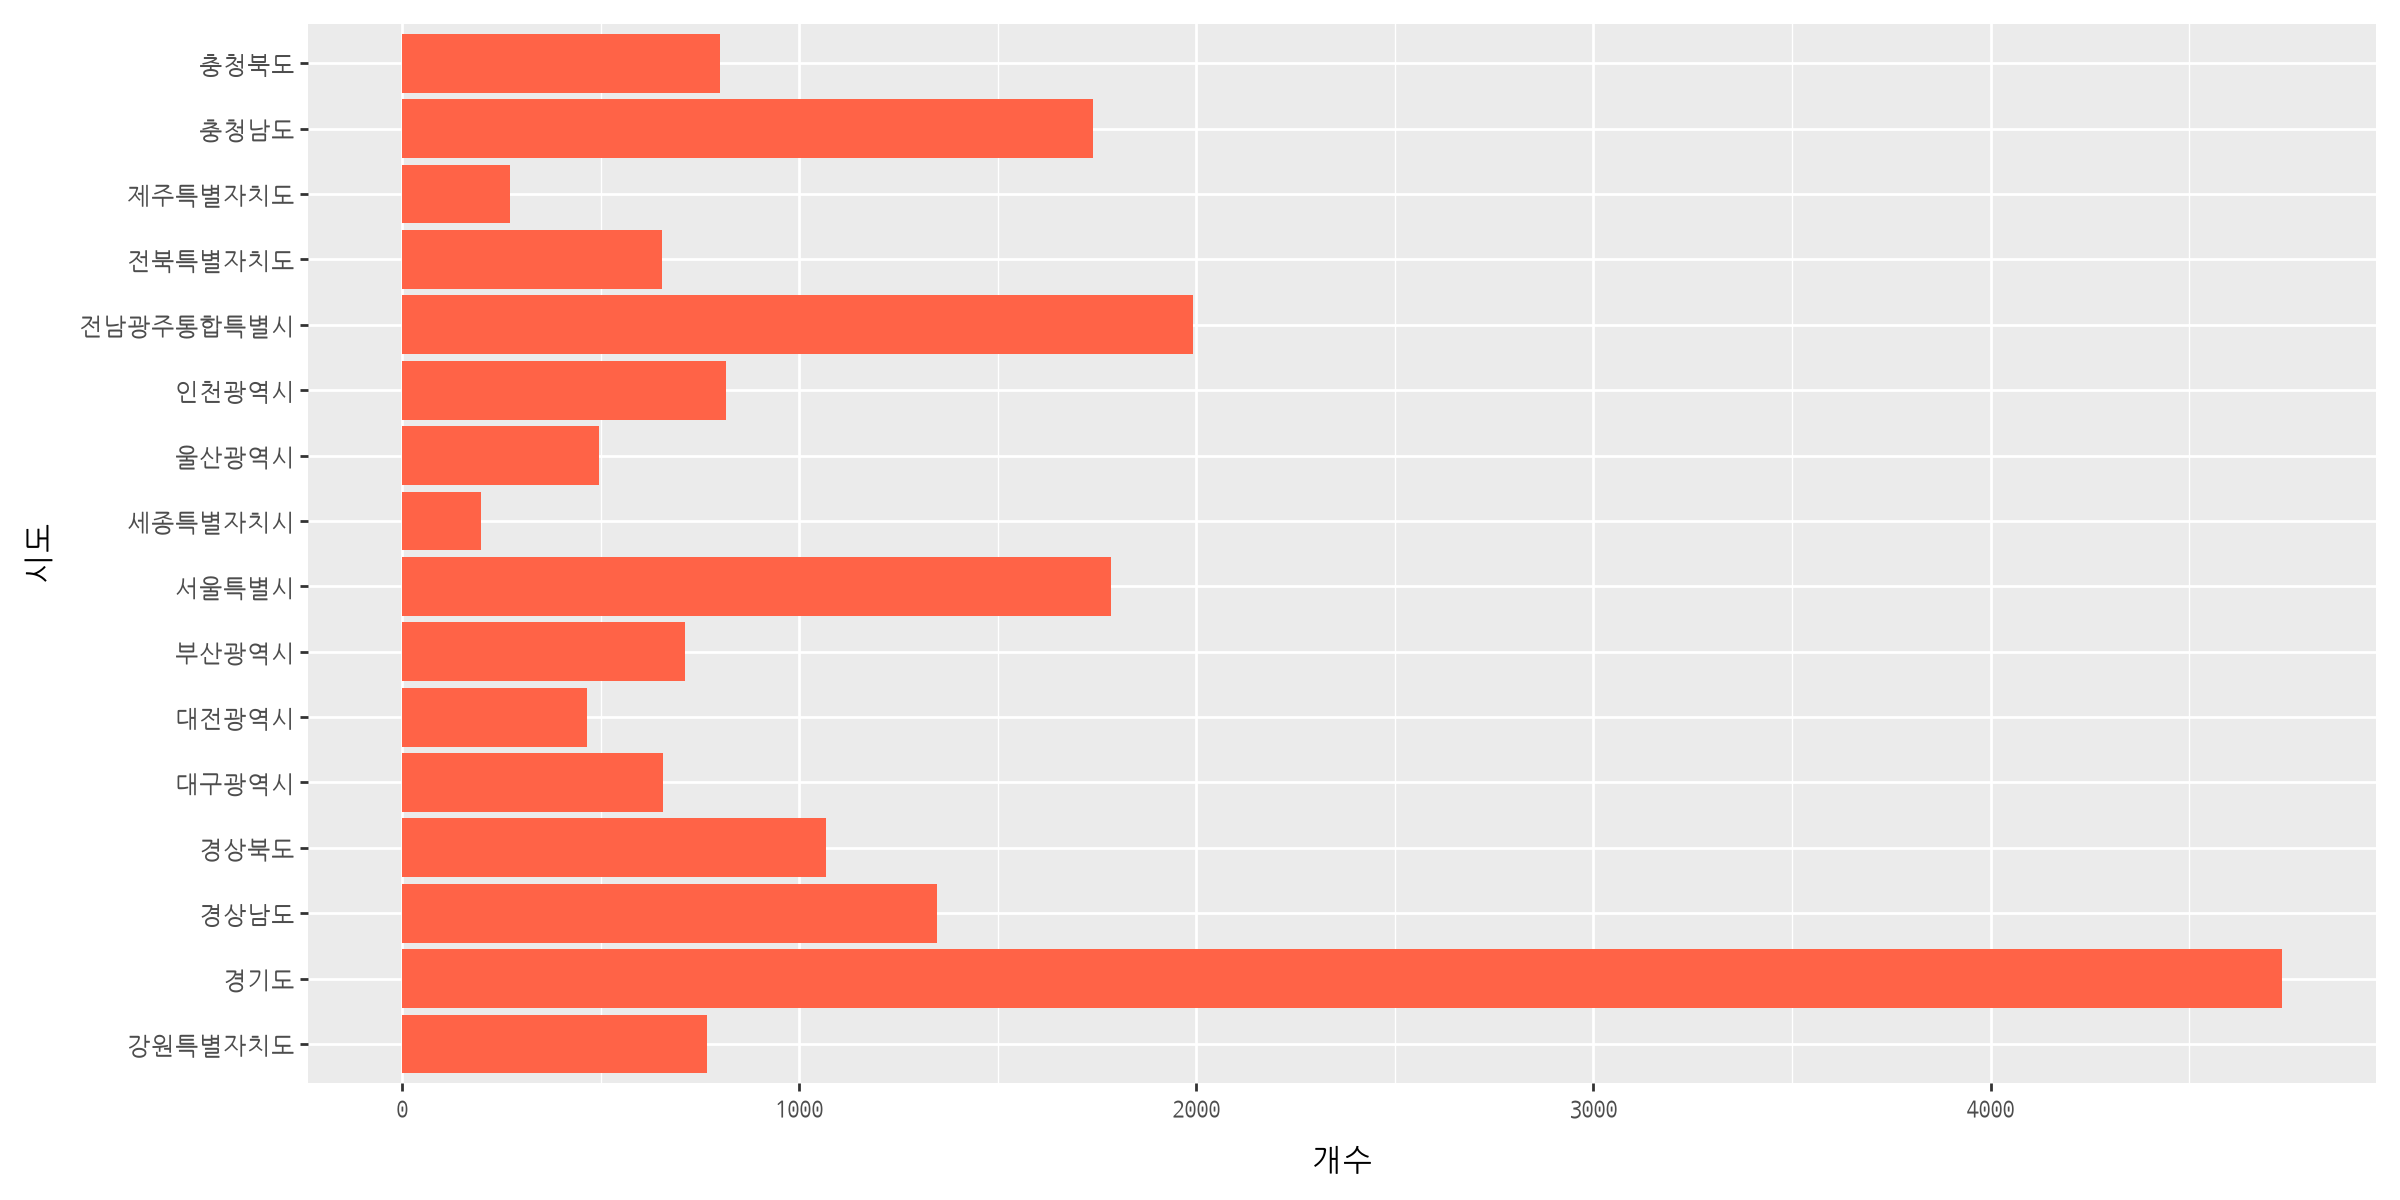

In [47]:
(
    ggplot(park_sido, aes(x='시도', y='개수'))
        + geom_bar(stat='identity', position='dodge', fill='tomato')
        + coord_flip()
        + theme(text=element_text(family='NanumGothicCoding'), figure_size=(12, 6))
)

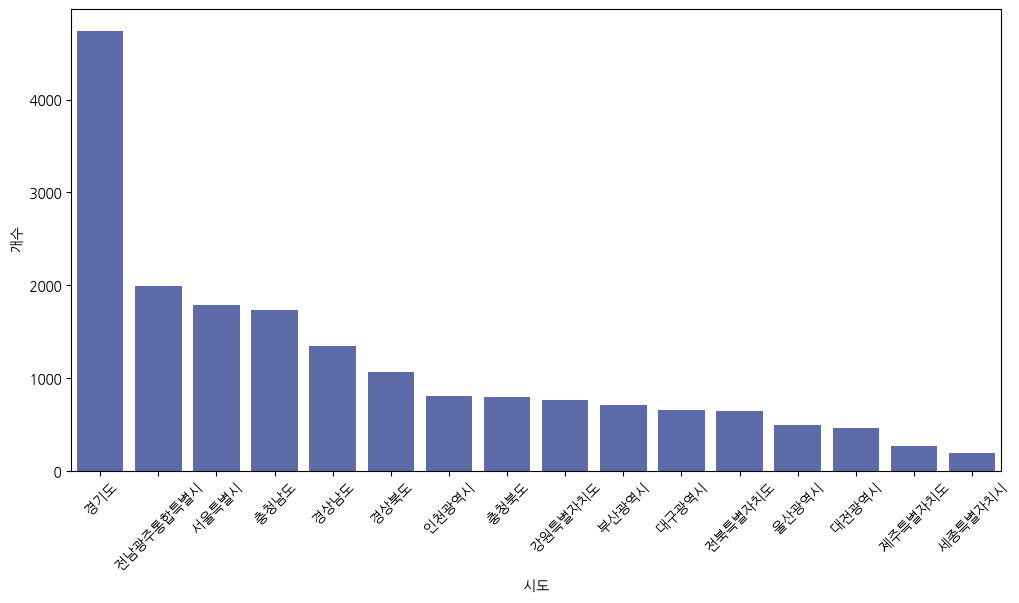

In [48]:
plt.figure(figsize=(12, 6))
# palette 속성을 사용하면 matplotlib/seaborn이 제공하는 컬러 팔레트를 사용해서 색상을 지정할 수 있다.
ax = sns.barplot(park_sido, x='시도', y='개수', color='#5063B5')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

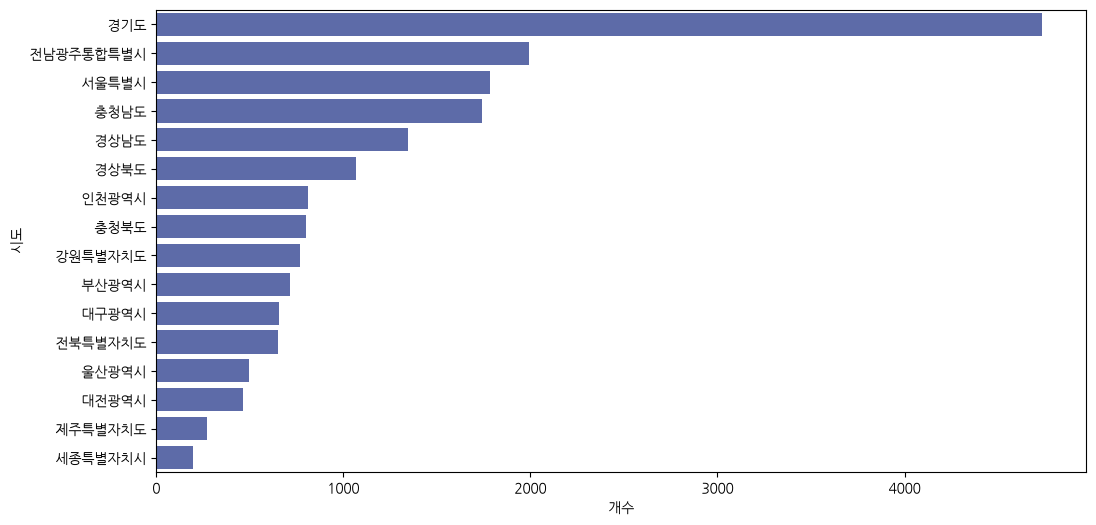

In [49]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(park_sido, x='개수', y='시도', color='#5063B5')
plt.show()

경기도 성남시 공원 분포 지도 시각화

In [50]:
data = park_202607[park_202607.주소2 == '성남시']
data.head()

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4,공원면적비율
12990,41135-00014,황새울공원,체육공원,경기도 성남시 분당구 황새울로 287,"경기도 성남시 분당구 수내동 42, 43",37.383256,127.118142,37957.0,경기도,성남시,분당구,황새울로,1.948256
12991,41135-00013,중앙공원,근린공원,경기도 성남시 분당구 성남대로 550,"경기도 성남시 분당구 수내동 65, 66",37.380301,127.121173,420982.1,경기도,성남시,분당구,성남대로,6.488313
12992,41135-00012,당골공원,근린공원,경기도 성남시 분당구 분당동 37,경기도 성남시 분당구 분당동 37,37.372234,127.129797,31128.8,경기도,성남시,분당구,분당동,1.764336
12993,41135-00011,맹산공원,근린공원,경기도 성남시 분당구 분당동 64-1,경기도 성남시 분당구 분당동 64-1,37.369425,127.132883,103828.1,경기도,성남시,분당구,분당동,3.222237
12994,41135-00010,태현공원,근린공원,경기도 성남시 분당구 분당동 88,경기도 성남시 분당구 분당동 88,37.369531,127.143577,16319.5,경기도,성남시,분당구,분당동,1.277478


In [51]:
sungnam_map = folium.Map(location=[data.위도.mean(), data.경도.mean()], zoom_start=13)
for i in data.index:
    popup = folium.Popup('{}: {}'.format(data.loc[i, '공원명'], data.loc[i, '도로명주소']), max_width=300)
    icon = folium.Icon(color='darkpurple', icon='flag')
    folium.Marker(
        location=[data.loc[i, '위도'], data.loc[i, '경도']], 
        popup=popup,
        icon=icon
    ).add_to(sungnam_map)
sungnam_map.save('./output/sungnam_map.html')
sungnam_map

In [52]:
sungnam_map = folium.Map(location=[data.위도.mean(), data.경도.mean()], zoom_start=13)
for i in data.index:
    popup = folium.Popup('{}: {}'.format(data.loc[i, '공원명'], data.loc[i, '도로명주소']), max_width=300)
    
    folium.CircleMarker(
        location=[data.loc[i, '위도'], data.loc[i, '경도']], 
        popup=popup,
        radius=data.loc[i, '공원면적비율'],
        color='red',
        fill_color='blue'
    ).add_to(sungnam_map)
    
sungnam_map.save('./output/sungnam_map.html')
sungnam_map

서울특별시의 전체 공원 개수에 대한 각 구의 공원의 비율 지도 시각화

In [128]:
park_seoul = park_202607[park_202607.주소1 == '서울특별시']
park_seoul

,관리번호,공원명,공원구분,도로명주소,지번주소,위도,경도,공원면적,주소1,주소2,주소3,주소4,공원면적비율
2054,11530-00058,현화,소공원,서울특별시 구로구 고척동 342-1,서울특별시 구로구 고척동 342-1,37.504324,126.860097,720.00,서울특별시,구로구,고척동,342-1,0.268328
2055,11530-00057,구로동(다울),소공원,서울특별시 구로구 구로동 1286-1,서울특별시 구로구 구로동 1286-1,37.492536,126.888217,243.39,서울특별시,구로구,구로동,1286-1,0.156010
2056,11530-00056,무궁화,소공원,서울특별시 구로구 고척동 341-2,서울특별시 구로구 고척동 341-2,37.504959,126.865056,1166.00,서울특별시,구로구,고척동,341-2,0.341467
2057,11530-00055,개봉동과장미,소공원,서울특별시 구로구 개봉동 345-14,서울특별시 구로구 개봉동 345-14,37.488101,126.854735,657.20,서울특별시,구로구,개봉동,345-14,0.256359
2058,11530-00054,갈매,소공원,서울특별시 구로구 온수동 155-4,서울특별시 구로구 온수동 155-4,37.496700,126.822808,3200.10,서울특별시,구로구,온수동,155-4,0.565694
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,11305-00045,솔밭근린공원,근린공원,서울특별시 강북구 우이동 80,서울특별시 강북구 우이동 80,37.653008,127.012253,34955.00,서울특별시,강북구,우이동,80,1.869626
18211,11305-00044,장미원,어린이공원,서울특별시 강북구 수유2동 276-10,서울특별시 강북구 수유2동 276-10,37.646469,127.015728,340.00,서울특별시,강북구,수유2동,276-10,0.184391
18212,11305-00043,빨래골,어린이공원,서울특별시 강북구 수유1동 475-115,서울특별시 강북구 수유1동 475-115,37.629423,127.014853,476.00,서울특별시,강북구,수유1동,475-115,0.218174
18213,11305-00042,무너미,어린이공원,서울특별시 강북구 수유동 281-2,서울특별시 강북구 수유동 281-2,37.646065,127.012741,380.00,서울특별시,강북구,수유동,281-2,0.194936


In [129]:
park_seoul_count = pd.DataFrame(park_seoul.주소2.value_counts())
park_seoul_count.head()

,count
주소2,
강서구,152
강남구,146
송파구,140
서초구,128
은평구,105


In [130]:
lat = pd.DataFrame(park_seoul.groupby('주소2').위도.mean())
lon = pd.DataFrame(park_seoul.groupby('주소2').경도.mean())
park_seoul_lat_lon = pd.concat([lat, lon], axis=1)
park_seoul_lat_lon.head()

,위도,경도
주소2,,
강남구,37.493308,127.064907
강동구,37.549237,127.147563
강북구,37.628434,127.023932
강서구,37.554768,126.838244
관악구,37.477111,126.940268


In [131]:
data = park_seoul_count.merge(park_seoul_lat_lon, left_index=True, right_index=True).reset_index()
data.columns = ['구', '개수', '위도', '경도']
# CircleMarker()의 radius 속성값으로 정수를 지정할 수 없기때문에 astype() 메소드로 실수로 데이터 타입을 변경한다.
data['개수'] = data.개수.astype(float)
data

,구,개수,위도,경도
0,강서구,152.0,37.554768,126.838244
1,강남구,146.0,37.493308,127.064907
2,송파구,140.0,37.500552,127.123324
3,서초구,128.0,37.482046,127.021066
4,은평구,105.0,37.610376,126.920624
5,양천구,96.0,37.524695,126.853601
6,마포구,90.0,37.558088,126.921454
7,관악구,75.0,37.477111,126.940268
8,강동구,74.0,37.549237,127.147563
9,서대문구,67.0,37.578938,126.931755


In [132]:
seoul_map = folium.Map(location=[data.위도.mean(), data.경도.mean()], zoom_start=11)
for i in data.index:
    popup = folium.Popup('{}: {}'.format(data.loc[i, '구'], data.loc[i, '개수']), max_width=300)
    
    folium.CircleMarker(
        location=[data.loc[i, '위도'], data.loc[i, '경도']], 
        popup=popup,
        radius=data.loc[i, '개수'] / 2,
        color='red',
        fill_color='blue'
    ).add_to(seoul_map)
    
seoul_map.save('./output/seoul_map.html')
seoul_map